# Figures from Akins and Hofstadter 2026
## 2. Model perturbations, spectral and angular response 

### Imports 

In [2]:
import os 
import numpy as np 
import scipy.constants as spc
import matplotlib.pyplot as plt 
from tqdm.auto import tqdm 

from eccm_mrtm import eccm, mrtm
module_dir = eccm.__path__[0]
plt.style.use('../eccm.mplstyle')


### Basic spectrum for Saturn 

<>:182: SyntaxWarning: invalid escape sequence '\c'
<>:182: SyntaxWarning: invalid escape sequence '\c'
/var/folders/zg/yqp2bsw569ngkkjdlpj0b5cw0000gq/T/ipykernel_41272/3019173913.py:182: SyntaxWarning: invalid escape sequence '\c'
  ax2.set_ylabel('R(50$^\circ$) %')


/var/folders/zg/yqp2bsw569ngkkjdlpj0b5cw0000gq/T/ipykernel_41272/3019173913.py:188: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axins.yaxis.set_ticklabels(axins.yaxis.get_ticklabels(), backgroundcolor='w')


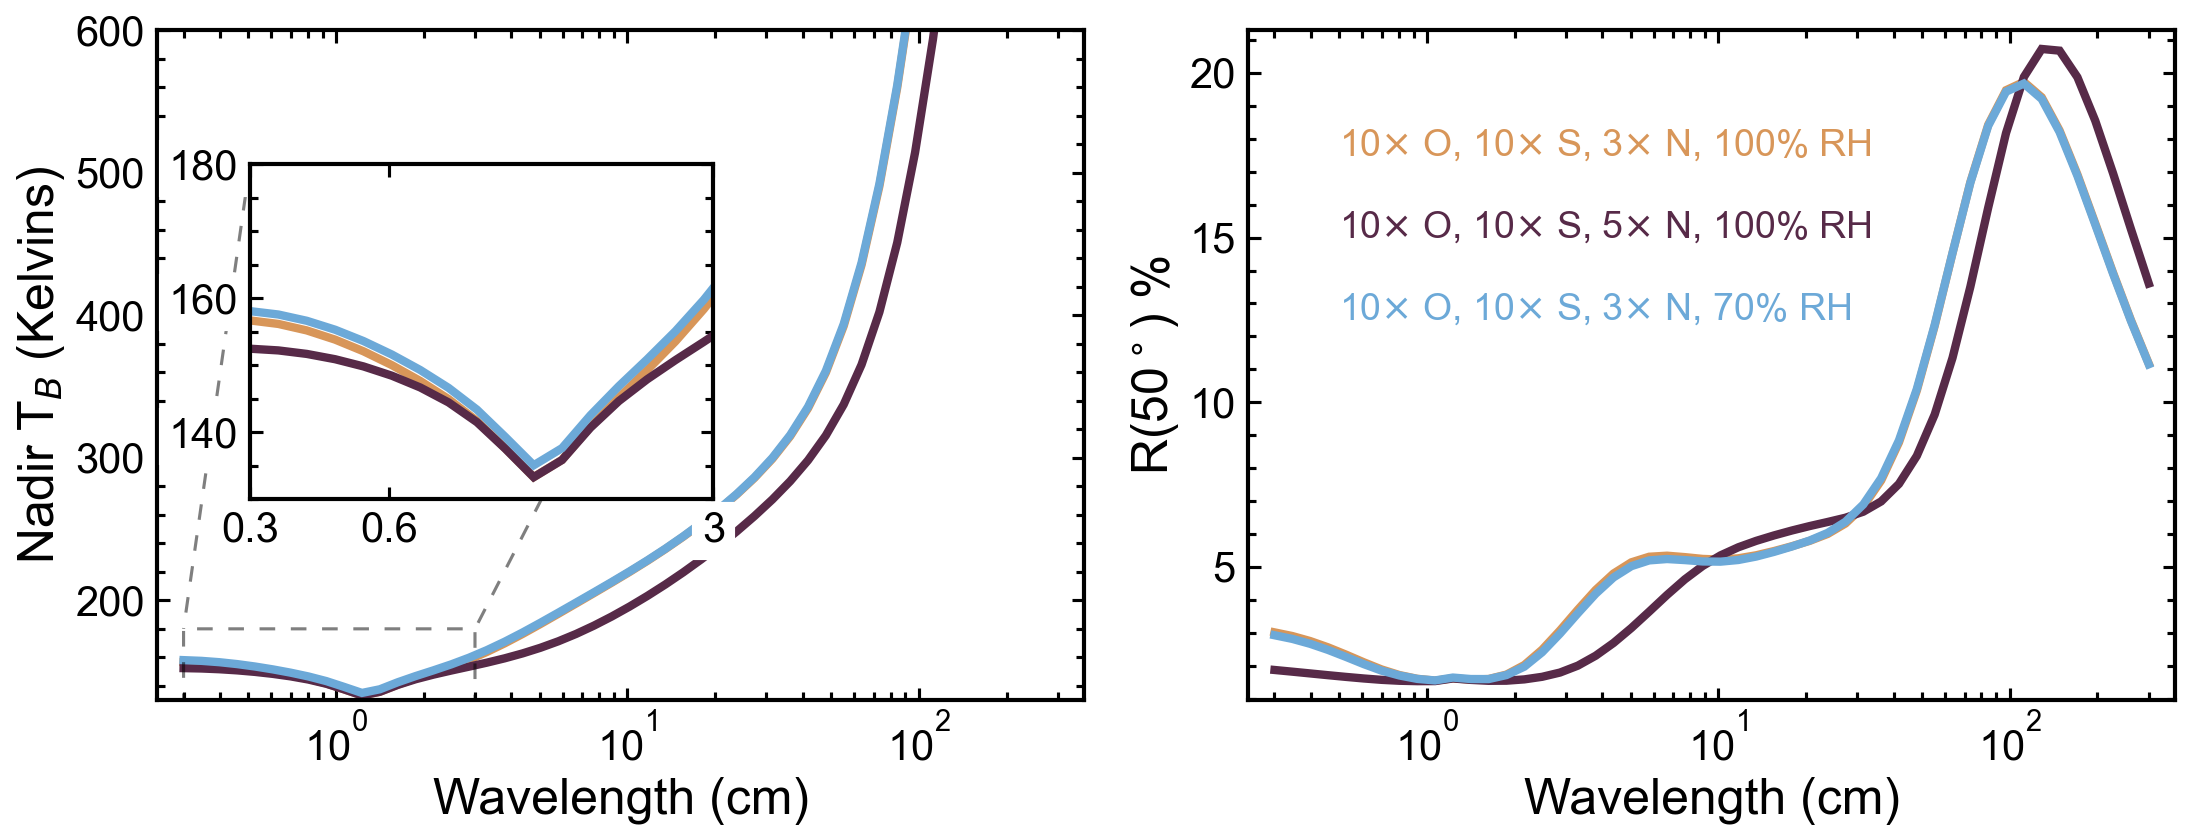

In [ ]:
wave_cm = np.logspace(np.log10(0.3), np.log10(300), 50) 
freq_ghz = spc.c / (wave_cm * 1e-2) * 1e-9 

p_grid = np.logspace(2, 10, 2500)
saturn_gravity = 10.44  # m/s2 
planet_radius = 60268  # km 

# Reference case
data_dir = eccm.__path__[0]
saturn_ro = np.loadtxt(os.path.join(data_dir, 'data/ro_profiles/saturn_cassini_schinder2011.txt'), skiprows=3, delimiter=',')
saturn_pressure = saturn_ro[:, 0] * 1e2  # Pa
saturn_temperature = saturn_ro[:, 1]

gases1 = eccm.solar_concentration() 
# Case 1 - Nominal - 10X O, 10X S, 3XN
gases = [eccm.GasInput('H2O', deep=10*gases1['O'], rh=1.), 
         eccm.GasInput('NH3', deep=3*gases1['N'], rh=1.), 
         eccm.GasInput('H2S', deep=10*gases1['S'], rh=1.), 
         eccm.GasInput('CH4', deep=10*gases1['C'], rh=1.), 
         ]

result  = eccm.run_eccm(p_grid, saturn_pressure, saturn_temperature, saturn_gravity,
                                                 gases=gases, bulk_h2=0.88, bulk_he=0.12,
                                                 latent_heat_update=True, force_reference_above_pressure=1.*spc.bar, 
                                                 use_compressibility=True)

pressure_grid = result['pressure']
temperature_grid = result['temperature']
altitude_grid = result['altitude']
x_h2o = result['gas_profiles']['H2O']
x_nh3 = result['gas_profiles']['NH3']
x_h2s = result['gas_profiles']['H2S']
x_ch4 = result['gas_profiles']['CH4']
x_ph3 = np.zeros(x_ch4.shape)
x_h2=0.88 * np.ones(x_ch4.shape)
x_he=0.12 * np.ones(x_ch4.shape)

a_h2osolid = result['aerosol_densities']['H2O']['solid']
a_h2oliquid = result['aerosol_densities']['H2O']['liquid']
a_nh3solid = result['aerosol_densities']['NH3']['solid']
a_nh3liquid = result['aerosol_densities']['NH3']['liquid']
a_h2ssolid = result['aerosol_densities']['H2S']['solid']
a_h2sliquid = result['aerosol_densities']['H2S']['liquid']
a_ch4solid = result['aerosol_densities']['CH4']['solid']
a_ch4liquid = result['aerosol_densities']['CH4']['liquid']
a_h2osolution = result['aerosol_densities']['H2O_NH3_SOLUTION']['liquid']
a_nh4sh = result['aerosol_densities']['NH4SH']['solid']

minloc = np.argmin(abs(pressure_grid / spc.bar - 1e-3))
maxloc = np.argmin(abs(pressure_grid / spc.bar - 1000e3))
slc = slice(maxloc, minloc, 3)
incang_deg = 0. 
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
ref_spec1 = Tup 
incang_deg = 50. 
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
ldspec = Tup 
R50_1 = (ref_spec1 - ldspec) / ref_spec1 * 1e2 

# Case 2 - Mid - 10X O, 10X S, 5XN
gases = [eccm.GasInput('H2O', deep=10*gases1['O'], rh=1.), 
         eccm.GasInput('NH3', deep=5*gases1['N'], rh=1.), 
         eccm.GasInput('H2S', deep=10*gases1['S'], rh=1.), 
         eccm.GasInput('CH4', deep=10*gases1['C'], rh=1.), 
         ]

result  = eccm.run_eccm(p_grid, saturn_pressure, saturn_temperature, saturn_gravity,
                                                 gases=gases, bulk_h2=0.88, bulk_he=0.12,
                                                 latent_heat_update=True, force_reference_above_pressure=1.*spc.bar, 
                                                 use_compressibility=True)

pressure_grid = result['pressure']
temperature_grid = result['temperature']
altitude_grid = result['altitude']
x_h2o = result['gas_profiles']['H2O']
x_nh3 = result['gas_profiles']['NH3']
x_h2s = result['gas_profiles']['H2S']
x_ch4 = result['gas_profiles']['CH4']
x_ph3 = np.zeros(x_ch4.shape)
x_h2=0.88 * np.ones(x_ch4.shape)
x_he=0.12 * np.ones(x_ch4.shape)

a_h2osolid = result['aerosol_densities']['H2O']['solid']
a_h2oliquid = result['aerosol_densities']['H2O']['liquid']
a_nh3solid = result['aerosol_densities']['NH3']['solid']
a_nh3liquid = result['aerosol_densities']['NH3']['liquid']
a_h2ssolid = result['aerosol_densities']['H2S']['solid']
a_h2sliquid = result['aerosol_densities']['H2S']['liquid']
a_ch4solid = result['aerosol_densities']['CH4']['solid']
a_ch4liquid = result['aerosol_densities']['CH4']['liquid']
a_h2osolution = result['aerosol_densities']['H2O_NH3_SOLUTION']['liquid']
a_nh4sh = result['aerosol_densities']['NH4SH']['solid']

minloc = np.argmin(abs(pressure_grid / spc.bar - 1e-3))
maxloc = np.argmin(abs(pressure_grid / spc.bar - 1000e3))
slc = slice(maxloc, minloc, 3)
incang_deg = 0. 
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
ref_spec2 = Tup 
incang_deg = 50. 
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
ldspec = Tup 
R50_2 = (ref_spec2 - ldspec) / ref_spec2 * 1e2 


# Case 3 - Off - 10X O, 10X S, 3X N, 70% RH
gases = [eccm.GasInput('H2O', deep=10*gases1['O'], rh=0.7), 
         eccm.GasInput('NH3', deep=3*gases1['N'], rh=0.7), 
         eccm.GasInput('H2S', deep=10*gases1['S'], rh=1.), 
         eccm.GasInput('CH4', deep=10*gases1['C'], rh=1.), 
         ]

result  = eccm.run_eccm(p_grid, saturn_pressure, saturn_temperature, saturn_gravity,
                                                 gases=gases, bulk_h2=0.88, bulk_he=0.12,
                                                 latent_heat_update=True, force_reference_above_pressure=1.*spc.bar, 
                                                 use_compressibility=True)

pressure_grid = result['pressure']
temperature_grid = result['temperature']
altitude_grid = result['altitude']
x_h2o = result['gas_profiles']['H2O']
x_nh3 = result['gas_profiles']['NH3']
x_h2s = result['gas_profiles']['H2S']
x_ch4 = result['gas_profiles']['CH4']
x_ph3 = np.zeros(x_ch4.shape)
x_h2=0.88 * np.ones(x_ch4.shape)
x_he=0.12 * np.ones(x_ch4.shape)

a_h2osolid = result['aerosol_densities']['H2O']['solid']
a_h2oliquid = result['aerosol_densities']['H2O']['liquid']
a_nh3solid = result['aerosol_densities']['NH3']['solid']
a_nh3liquid = result['aerosol_densities']['NH3']['liquid']
a_h2ssolid = result['aerosol_densities']['H2S']['solid']
a_h2sliquid = result['aerosol_densities']['H2S']['liquid']
a_ch4solid = result['aerosol_densities']['CH4']['solid']
a_ch4liquid = result['aerosol_densities']['CH4']['liquid']
a_h2osolution = result['aerosol_densities']['H2O_NH3_SOLUTION']['liquid']
a_nh4sh = result['aerosol_densities']['NH4SH']['solid']

minloc = np.argmin(abs(pressure_grid / spc.bar - 1e-3))
maxloc = np.argmin(abs(pressure_grid / spc.bar - 1000e3))
slc = slice(maxloc, minloc, 3)
incang_deg = 0. 
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
ref_spec3 = Tup 
incang_deg = 50. 
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
ldspec = Tup 
R50_3 = (ref_spec3 - ldspec) / ref_spec3 * 1e2 

fig = plt.figure(figsize=(15, 6))
ax1 = fig.add_subplot(1,2,1)
ax2 = fig.add_subplot(1,2,2)
axins = ax1.inset_axes([0.1, 0.44, 0.5, 0.5], xlim=(3e-1, 3), ylim=(130, 180))

colors = [
    (240, 155, 45),   
    (170, 50, 135),   
    (45, 150, 225),   
]
colors = [(r/255, g/255, b/255) for r, g, b in colors]

ax1.plot(wave_cm, ref_spec1, color=colors[0], lw=2)
ax2.plot(wave_cm, R50_1, color=colors[0], lw=2)
axins.plot(wave_cm, ref_spec1, color=colors[0], lw=2)
ax1.plot(wave_cm, ref_spec2, color=colors[1], lw=2)
ax2.plot(wave_cm, R50_2, color=colors[1], lw=2)
axins.plot(wave_cm, ref_spec2, color=colors[1], lw=2)
ax1.plot(wave_cm, ref_spec3, color=colors[2], lw=2)
ax2.plot(wave_cm, R50_3, color=colors[2], lw=2)
axins.plot(wave_cm, ref_spec3, color=colors[2], lw=2)

ax2.text(3e-1, 16.55, r'10$\times$O, 10$\times$S, 3$\times$N, 100% RH', color=colors[0], fontsize=24)
ax2.text(3e-1, 15, r'10$\times$O, 10$\times$S, 5$\times$N, 100% RH', color=colors[1], fontsize=24)
ax2.text(3e-1, 13.45, r'10$\times$O, 10$\times$S, 3$\times$N, 70% RH', color=colors[2], fontsize=24)
insind = ax1.indicate_inset_zoom(axins, edgecolor="black", ls=(0, (5, 5)), alpha=1.)
insind.connectors[0].set_visible(False)
insind.connectors[1].set_visible(True)
insind.connectors[2].set_visible(False)
insind.connectors[3].set_visible(True)
ax1.set_xlabel('Wavelength (cm)')
ax2.set_xlabel('Wavelength (cm)')
ax1.set_ylabel('Nadir T$_B$ (Kelvins)')
ax2.set_ylabel('R(50$^\circ$) %')
ax1.set_xscale('log')
ax2.set_xscale('log')
axins.set_xscale('log')
axins.set_xticks([3e-1, 6e-1, 1., 2., 3.])
axins.set_xticklabels([3e-1, 6e-1, 1., 2., 3.], backgroundcolor="w")
axins.yaxis.set_ticklabels(axins.yaxis.get_ticklabels(), backgroundcolor='w')
axins.set()
axins.xaxis.minorticks_off()
ax1.set_ylim(130, 600)
fig.suptitle('SATURN', y=0.9, weight='bold')
ax1.text(2e2, 150, 'A', weight='bold', fontsize=24)
ax2.text(2e2, 2, 'B', weight='bold', fontsize=24)
fig.tight_layout()
fig.savefig('saturn_basic_spectrum.pdf') 

### Spectrum sensitivity for Saturn 

Deep ATM:   0%|          | 0/3 [00:00<?, ?it/s]

RH:   0%|          | 0/2 [00:00<?, ?it/s]

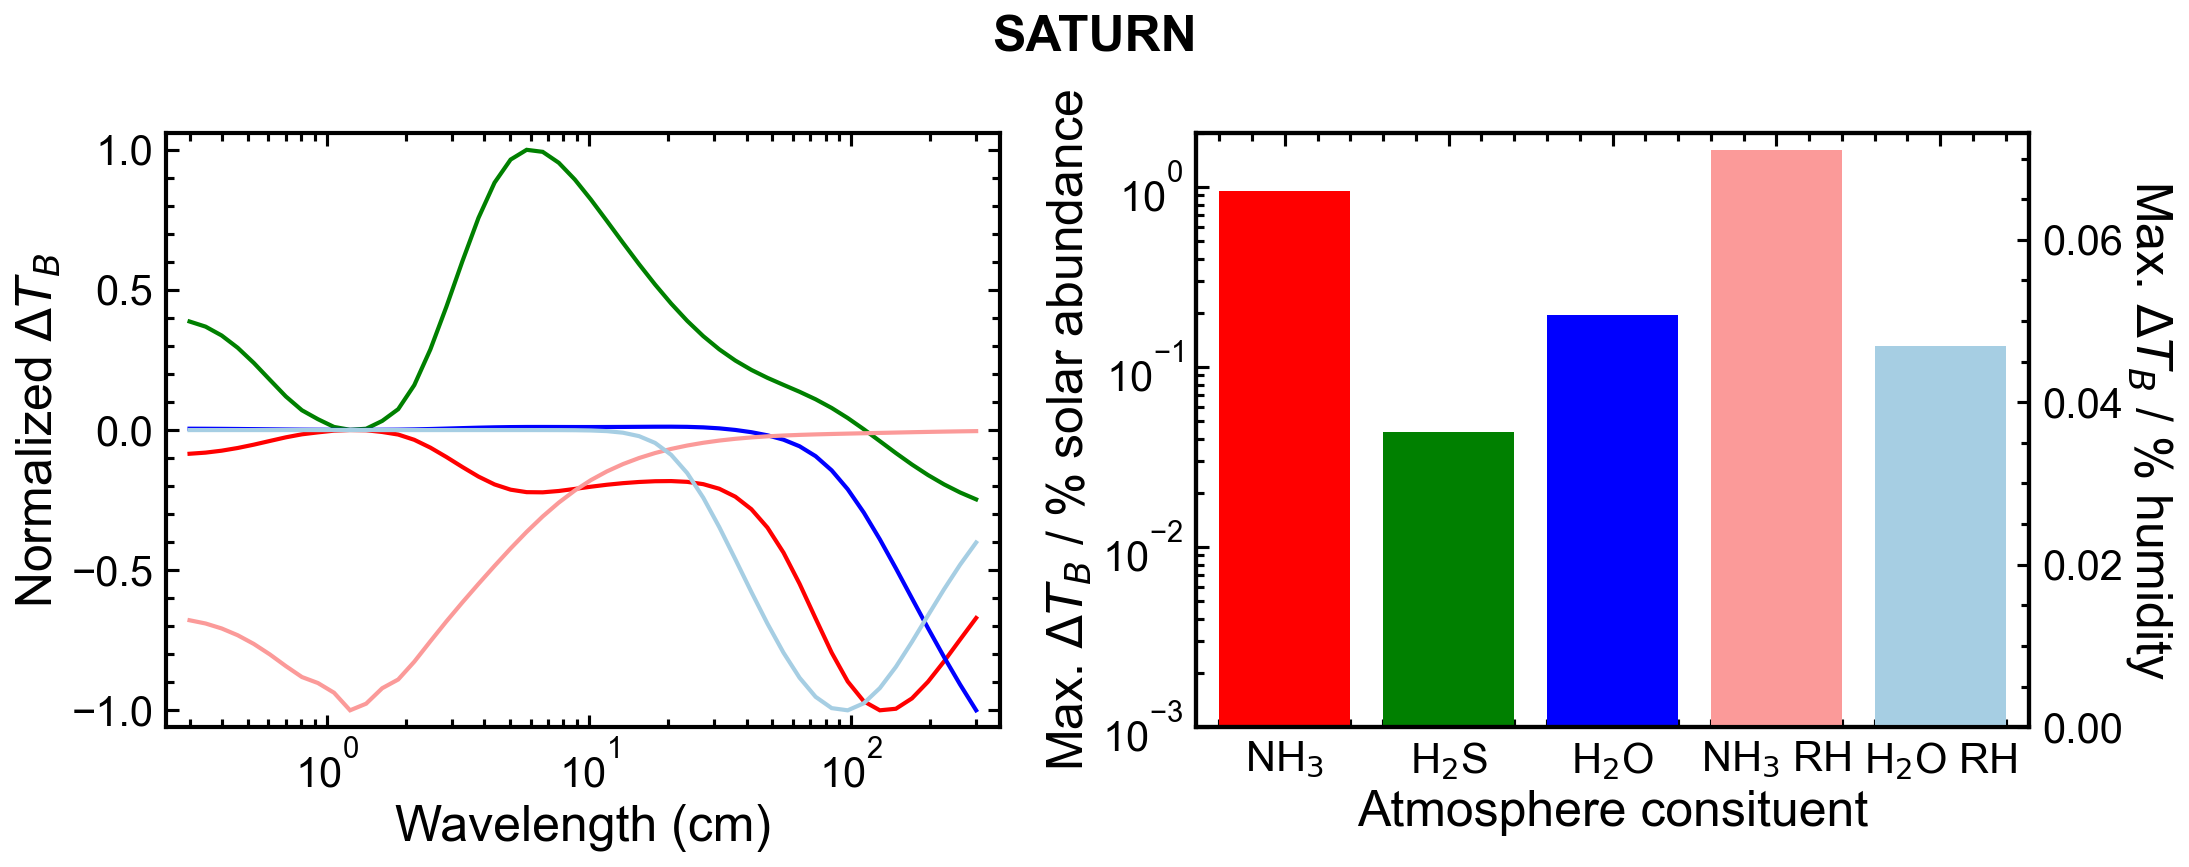

In [135]:
wave_cm = np.logspace(np.log10(0.3), np.log10(300), 50)  # One fn run takes 15s (30s for 100) 
freq_ghz = spc.c / (wave_cm * 1e-2) * 1e-9 
incang_deg = 0. 

step_gases = ['NH3', 'H2S', 'H2O']
rh_gases = ['NH3', 'H2O']
sg_psa = [1.48e-4, 2.89e-5, 1.07e-3]  # Solar ratios
label_dict = {'NH3': r'NH$_3$', 'H2S': r'H$_2$S','H2O': r'H$_2$O'}
paired_cmap = plt.get_cmap('Paired')
colors = ['r', 'g', 'b', paired_cmap(4), paired_cmap(0)]

p_grid = np.logspace(2, 10, 2500)
saturn_gravity = 10.44  # m/s2 
planet_radius = 60268  # km 

# Reference case
data_dir = eccm.__path__[0]
saturn_ro = np.loadtxt(os.path.join(data_dir, 'data/ro_profiles/saturn_cassini_schinder2011.txt'), skiprows=3, delimiter=',')
saturn_pressure = saturn_ro[:, 0] * 1e2  # Pa
saturn_temperature = saturn_ro[:, 1]

gases1 = eccm.solar_concentration() 
# Case 1 - Nominal - 10X O, 10X S, 3XN
gases = [eccm.GasInput('H2O', deep=10*gases1['O'], rh=0.7), 
         eccm.GasInput('NH3', deep=3*gases1['N'], rh=0.7), 
         eccm.GasInput('H2S', deep=10*gases1['S'], rh=1.), 
         eccm.GasInput('CH4', deep=10*gases1['C'], rh=1.), 
         ]

result  = eccm.run_eccm(p_grid, saturn_pressure, saturn_temperature, saturn_gravity,
                                                 gases=gases, bulk_h2=0.88, bulk_he=0.12,
                                                 latent_heat_update=True, force_reference_above_pressure=1.*spc.bar, 
                                                 use_compressibility=True)

pressure_grid = result['pressure']
temperature_grid = result['temperature']
altitude_grid = result['altitude']
x_h2o = result['gas_profiles']['H2O']
x_nh3 = result['gas_profiles']['NH3']
x_h2s = result['gas_profiles']['H2S']
x_ch4 = result['gas_profiles']['CH4']
x_ph3 = np.zeros(x_ch4.shape)
x_h2=0.88 * np.ones(x_ch4.shape)
x_he=0.12 * np.ones(x_ch4.shape)

a_h2osolid = result['aerosol_densities']['H2O']['solid']
a_h2oliquid = result['aerosol_densities']['H2O']['liquid']
a_nh3solid = result['aerosol_densities']['NH3']['solid']
a_nh3liquid = result['aerosol_densities']['NH3']['liquid']
a_h2ssolid = result['aerosol_densities']['H2S']['solid']
a_h2sliquid = result['aerosol_densities']['H2S']['liquid']
a_ch4solid = result['aerosol_densities']['CH4']['solid']
a_ch4liquid = result['aerosol_densities']['CH4']['liquid']
a_h2osolution = result['aerosol_densities']['H2O_NH3_SOLUTION']['liquid']
a_nh4sh = result['aerosol_densities']['NH4SH']['solid']


minloc = np.argmin(abs(pressure_grid / spc.bar - 1e-3))
maxloc = np.argmin(abs(pressure_grid / spc.bar - 1000e3))
slc = slice(maxloc, minloc, 3)
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
ref_spec = Tup 
this_jac_list = [] 

for j, sg in enumerate(tqdm(step_gases, desc='Deep ATM')):
    if sg == 'NH3': 
        use_deep_nh3 = 3*gases1['N'] + 1e-2 * sg_psa[0]
        use_deep_h2s = 10*gases1['S'] 
        use_deep_h2o = 10*gases1['O']
    elif sg == 'H2S': 
        use_deep_nh3 = 3*gases1['N'] 
        use_deep_h2s = 10*gases1['S'] + 1e-2 * sg_psa[1]
        use_deep_h2o = 10*gases1['O']
    else: 
        use_deep_nh3 = 3*gases1['N'] 
        use_deep_h2s = 10*gases1['S'] 
        use_deep_h2o = 10*gases1['O'] + 1e-2 * sg_psa[2]

    gases = [eccm.GasInput('H2O', deep=use_deep_h2o, rh=0.7), 
            eccm.GasInput('NH3', deep=use_deep_nh3, rh=0.7), 
            eccm.GasInput('H2S', deep=use_deep_h2s, rh=1.), 
            eccm.GasInput('CH4', deep=10*gases1['C'], rh=1.), 
            ]

    result  = eccm.run_eccm(p_grid, saturn_pressure, saturn_temperature, saturn_gravity,
                                                    gases=gases, bulk_h2=0.88, bulk_he=0.12,
                                                    latent_heat_update=True, force_reference_above_pressure=1.*spc.bar, 
                                                    use_compressibility=True)

    pressure_grid = result['pressure']
    temperature_grid = result['temperature']
    altitude_grid = result['altitude']
    x_h2o = result['gas_profiles']['H2O']
    x_nh3 = result['gas_profiles']['NH3']
    x_h2s = result['gas_profiles']['H2S']
    x_ch4 = result['gas_profiles']['CH4']
    x_ph3 = np.zeros(x_ch4.shape)
    x_h2=0.88 * np.ones(x_ch4.shape)
    x_he=0.12 * np.ones(x_ch4.shape)

    a_h2osolid = result['aerosol_densities']['H2O']['solid']
    a_h2oliquid = result['aerosol_densities']['H2O']['liquid']
    a_nh3solid = result['aerosol_densities']['NH3']['solid']
    a_nh3liquid = result['aerosol_densities']['NH3']['liquid']
    a_h2ssolid = result['aerosol_densities']['H2S']['solid']
    a_h2sliquid = result['aerosol_densities']['H2S']['liquid']
    a_ch4solid = result['aerosol_densities']['CH4']['solid']
    a_ch4liquid = result['aerosol_densities']['CH4']['liquid']
    a_h2osolution = result['aerosol_densities']['H2O_NH3_SOLUTION']['liquid']
    a_nh4sh = result['aerosol_densities']['NH4SH']['solid']

    full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
    this_jac = (Tup - ref_spec) / 1e-2 
    this_jac_list.append(this_jac.copy()) 

for j, rhg in enumerate(tqdm(rh_gases, desc='RH')):
    if rhg == 'NH3': 
        use_nh3_rh = 0.7 + 1e-2 
        use_h2o_rh = 0.7 
    else: 
        use_nh3_rh = 0.7 
        use_h2o_rh = 0.7 + 1e-2 

    gases = [eccm.GasInput('H2O', deep=10*gases1['O'], rh=use_h2o_rh), 
         eccm.GasInput('NH3', deep=3*gases1['N'], rh=use_nh3_rh), 
         eccm.GasInput('H2S', deep=10*gases1['S'], rh=1.), 
         eccm.GasInput('CH4', deep=10*gases1['C'], rh=1.), 
         ]

    result  = eccm.run_eccm(p_grid, saturn_pressure, saturn_temperature, saturn_gravity,
                                                    gases=gases, bulk_h2=0.88, bulk_he=0.12,
                                                    latent_heat_update=True, force_reference_above_pressure=1.*spc.bar, 
                                                    use_compressibility=True)

    pressure_grid = result['pressure']
    temperature_grid = result['temperature']
    altitude_grid = result['altitude']
    x_h2o = result['gas_profiles']['H2O']
    x_nh3 = result['gas_profiles']['NH3']
    x_h2s = result['gas_profiles']['H2S']
    x_ch4 = result['gas_profiles']['CH4']
    x_ph3 = np.zeros(x_ch4.shape)
    x_h2=0.88 * np.ones(x_ch4.shape)
    x_he=0.12 * np.ones(x_ch4.shape)

    a_h2osolid = result['aerosol_densities']['H2O']['solid']
    a_h2oliquid = result['aerosol_densities']['H2O']['liquid']
    a_nh3solid = result['aerosol_densities']['NH3']['solid']
    a_nh3liquid = result['aerosol_densities']['NH3']['liquid']
    a_h2ssolid = result['aerosol_densities']['H2S']['solid']
    a_h2sliquid = result['aerosol_densities']['H2S']['liquid']
    a_ch4solid = result['aerosol_densities']['CH4']['solid']
    a_ch4liquid = result['aerosol_densities']['CH4']['liquid']
    a_h2osolution = result['aerosol_densities']['H2O_NH3_SOLUTION']['liquid']
    a_nh4sh = result['aerosol_densities']['NH4SH']['solid']

    full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
    this_jac = (Tup - ref_spec) / 1e-2 
    this_jac_list.append(this_jac.copy()) 

fig, axs = plt.subplots(1, 2, figsize=(15, 6))
tax = axs[1].twinx()

for j, tj in enumerate(this_jac_list): 
    if j < 3: 
        use_label = label_dict[step_gases[j]]
        axs[1].bar(use_label, np.max(abs(tj)) * 1e-2 , color=colors[j], label=use_label)
    else:
        use_label = label_dict[rh_gases[j - 3]] + ' RH' 
        tax.bar(use_label, np.max(abs(tj)) * 1e-2 , color=colors[j], label=use_label)
    axs[0].semilogx(wave_cm, tj / np.max(abs(tj)), color=colors[j], label=use_label)
        
axs[0].set_xlabel('Wavelength (cm)')
axs[0].set_ylabel(r'Normalized $\Delta T_B$')
axs[1].set_xlabel('Atmosphere consituent')
axs[1].set_ylabel(r'Max. $\Delta T_B$ / % solar abundance')
tax.set_ylabel(r'Max. $\Delta T_B$ / % humidity', rotation=-90, labelpad=25)
# axs[0].legend()
axs[1].set_yscale('log')
axs[1].set_ylim(1e-3, 2)
fig.suptitle('SATURN', weight='bold')
fig.tight_layout()    
fig.savefig('saturn_dTB.pdf')

### Basic spectrum for Uranus

<>:173: SyntaxWarning: invalid escape sequence '\c'
<>:173: SyntaxWarning: invalid escape sequence '\c'
/var/folders/zg/yqp2bsw569ngkkjdlpj0b5cw0000gq/T/ipykernel_41272/1522121951.py:173: SyntaxWarning: invalid escape sequence '\c'
  ax2.set_ylabel('R(50$^\circ$) %')


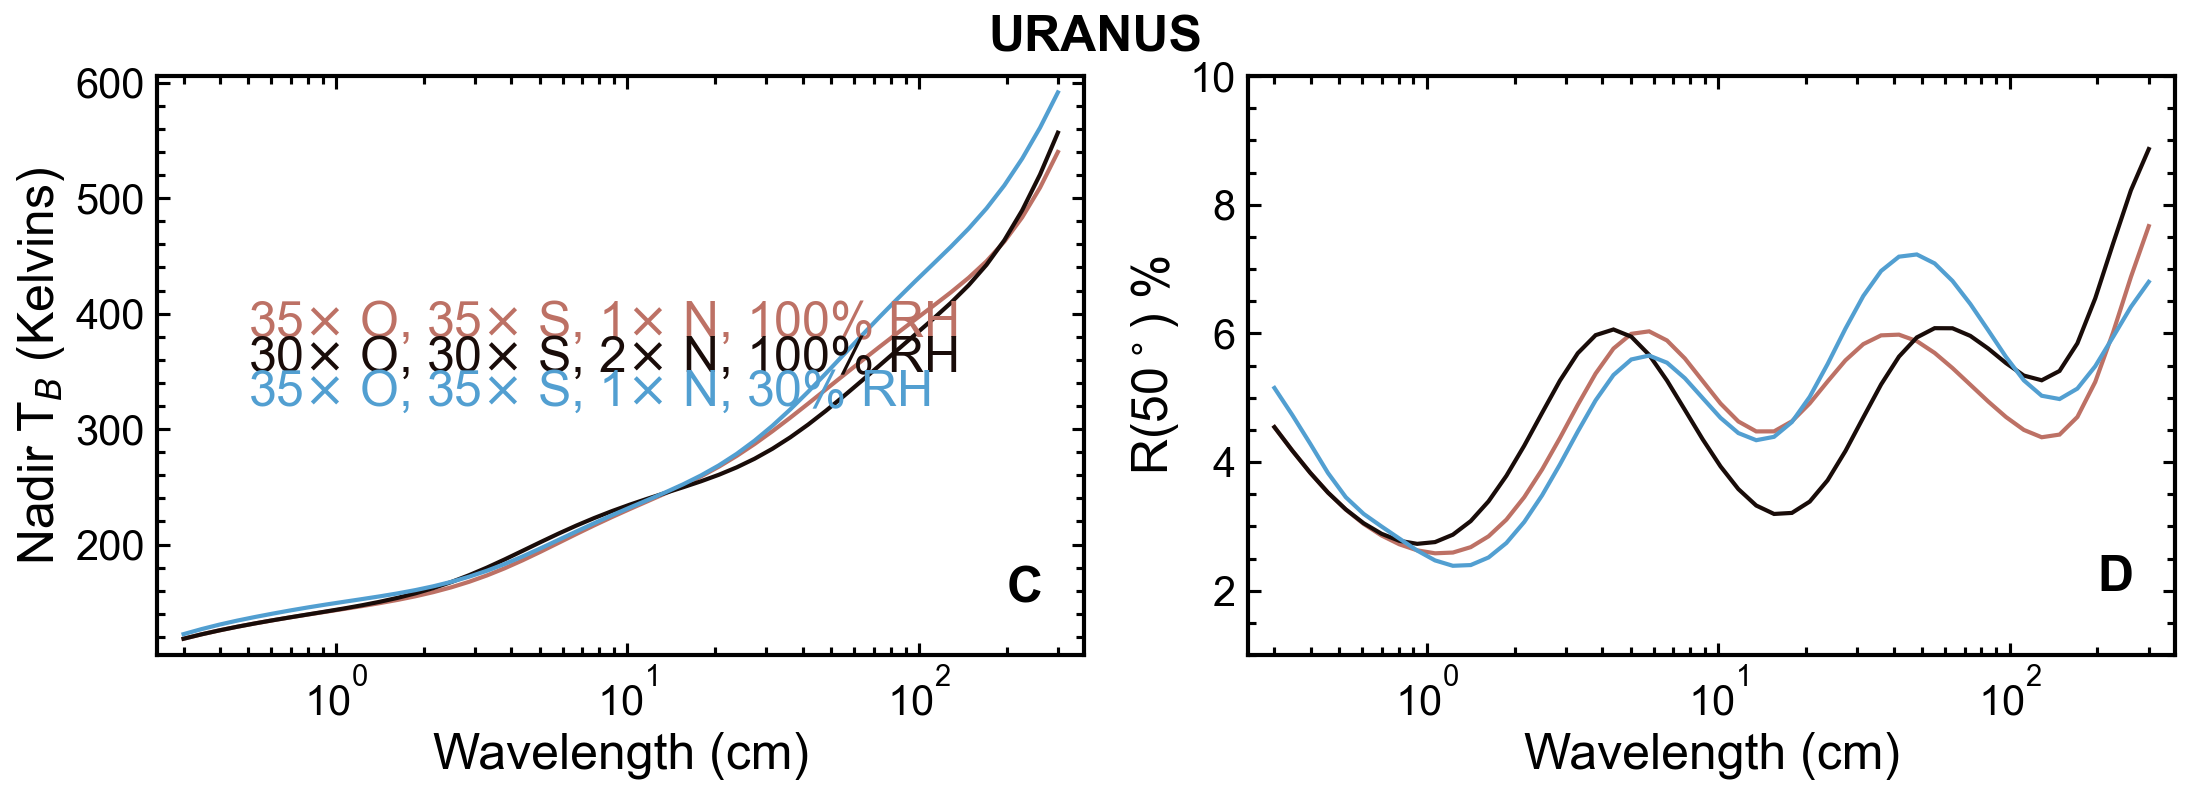

In [ ]:
wave_cm = np.logspace(np.log10(0.3), np.log10(300), 50)  # One fn run takes 15s (30s for 100) 
freq_ghz = spc.c / (wave_cm * 1e-2) * 1e-9 

p_grid = np.logspace(2, 10, 2500)
uranus_gravity = 8.87  # m/s2 
planet_radius = 25559  # km 

# Reference case
data_dir = eccm.__path__[0]
uranus_ro = np.loadtxt(os.path.join(data_dir, 'data/ro_profiles/uranus_voyager2_lindal1987.txt'), skiprows=3, delimiter=',')
uranus_pressure = uranus_ro[:, 0] * 1e2  # Pa
uranus_temperature = uranus_ro[:, 1]

gases = [eccm.GasInput('H2O', deep=35*gases1['O'], rh=1.), 
         eccm.GasInput('NH3', deep=1*gases1['N'], rh=1.), 
         eccm.GasInput('H2S', deep=35*gases1['S'], rh=1.), 
         eccm.GasInput('CH4', deep=50*gases1['C'], rh=1.), 
]

result  = eccm.run_eccm(p_grid, uranus_pressure, uranus_temperature, uranus_gravity,
                                                 gases=gases, bulk_h2=0.85, bulk_he=0.15,
                                                 latent_heat_update=True, force_reference_above_pressure=1.*spc.bar, 
                                                 use_compressibility=True)

pressure_grid = result['pressure']
temperature_grid = result['temperature']
altitude_grid = result['altitude']
x_h2o = result['gas_profiles']['H2O']
x_nh3 = result['gas_profiles']['NH3']
x_h2s = result['gas_profiles']['H2S']
x_ch4 = result['gas_profiles']['CH4']
x_ph3 = np.zeros(x_ch4.shape)
x_h2=0.85 * np.ones(x_ch4.shape)
x_he=0.15 * np.ones(x_ch4.shape)

a_h2osolid = result['aerosol_densities']['H2O']['solid']
a_h2oliquid = result['aerosol_densities']['H2O']['liquid']
a_nh3solid = result['aerosol_densities']['NH3']['solid']
a_nh3liquid = result['aerosol_densities']['NH3']['liquid']
a_h2ssolid = result['aerosol_densities']['H2S']['solid']
a_h2sliquid = result['aerosol_densities']['H2S']['liquid']
a_ch4solid = result['aerosol_densities']['CH4']['solid']
a_ch4liquid = result['aerosol_densities']['CH4']['liquid']
a_h2osolution = result['aerosol_densities']['H2O_NH3_SOLUTION']['liquid']
a_nh4sh = result['aerosol_densities']['NH4SH']['solid']

minloc = np.argmin(abs(pressure_grid / spc.bar - 1e-3))
maxloc = np.argmin(abs(pressure_grid / spc.bar - 1000e3))
slc = slice(maxloc, minloc, 3)
incang_deg = 0. 
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
ref_spec1 = Tup 
incang_deg = 50. 
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
ldspec = Tup 
R50_1 = (ref_spec1 - ldspec) / ref_spec1 * 1e2 

# Case 2 - Mid 
gases = [eccm.GasInput('H2O', deep=30*gases1['O'], rh=1.), 
         eccm.GasInput('NH3', deep=2*gases1['N'], rh=1.), 
         eccm.GasInput('H2S', deep=30*gases1['S'], rh=1.), 
         eccm.GasInput('CH4', deep=50*gases1['C'], rh=1.), 
]

result  = eccm.run_eccm(p_grid, uranus_pressure, uranus_temperature, uranus_gravity,
                                                 gases=gases, bulk_h2=0.85, bulk_he=0.15,
                                                 latent_heat_update=True, force_reference_above_pressure=1.*spc.bar, 
                                                 use_compressibility=True)

pressure_grid = result['pressure']
temperature_grid = result['temperature']
altitude_grid = result['altitude']
x_h2o = result['gas_profiles']['H2O']
x_nh3 = result['gas_profiles']['NH3']
x_h2s = result['gas_profiles']['H2S']
x_ch4 = result['gas_profiles']['CH4']
x_ph3 = np.zeros(x_ch4.shape)
x_h2=0.85 * np.ones(x_ch4.shape)
x_he=0.15 * np.ones(x_ch4.shape)

a_h2osolid = result['aerosol_densities']['H2O']['solid']
a_h2oliquid = result['aerosol_densities']['H2O']['liquid']
a_nh3solid = result['aerosol_densities']['NH3']['solid']
a_nh3liquid = result['aerosol_densities']['NH3']['liquid']
a_h2ssolid = result['aerosol_densities']['H2S']['solid']
a_h2sliquid = result['aerosol_densities']['H2S']['liquid']
a_ch4solid = result['aerosol_densities']['CH4']['solid']
a_ch4liquid = result['aerosol_densities']['CH4']['liquid']
a_h2osolution = result['aerosol_densities']['H2O_NH3_SOLUTION']['liquid']
a_nh4sh = result['aerosol_densities']['NH4SH']['solid']

minloc = np.argmin(abs(pressure_grid / spc.bar - 1e-3))
maxloc = np.argmin(abs(pressure_grid / spc.bar - 1000e3))
slc = slice(maxloc, minloc, 3)
incang_deg = 0. 
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
ref_spec2 = Tup 
incang_deg = 50. 
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
ldspec = Tup 
R50_2 = (ref_spec2 - ldspec) / ref_spec2 * 1e2 


# Case 3 - Off - 10X O, 10X S, 3X N, 50% RH
gases = [eccm.GasInput('H2O', deep=35*gases1['O'], rh=0.3), 
         eccm.GasInput('NH3', deep=1*gases1['N'], rh=1.), 
         eccm.GasInput('H2S', deep=35*gases1['S'], rh=0.3), 
         eccm.GasInput('CH4', deep=50*gases1['C'], rh=1.), 
]

result  = eccm.run_eccm(p_grid, uranus_pressure, uranus_temperature, uranus_gravity,
                                                 gases=gases, bulk_h2=0.85, bulk_he=0.15,
                                                 latent_heat_update=True, force_reference_above_pressure=1.*spc.bar, 
                                                 use_compressibility=True)

pressure_grid = result['pressure']
temperature_grid = result['temperature']
altitude_grid = result['altitude']
x_h2o = result['gas_profiles']['H2O']
x_nh3 = result['gas_profiles']['NH3']
x_h2s = result['gas_profiles']['H2S']
x_ch4 = result['gas_profiles']['CH4']
x_ph3 = np.zeros(x_ch4.shape)
x_h2=0.85 * np.ones(x_ch4.shape)
x_he=0.15 * np.ones(x_ch4.shape)

a_h2osolid = result['aerosol_densities']['H2O']['solid']
a_h2oliquid = result['aerosol_densities']['H2O']['liquid']
a_nh3solid = result['aerosol_densities']['NH3']['solid']
a_nh3liquid = result['aerosol_densities']['NH3']['liquid']
a_h2ssolid = result['aerosol_densities']['H2S']['solid']
a_h2sliquid = result['aerosol_densities']['H2S']['liquid']
a_ch4solid = result['aerosol_densities']['CH4']['solid']
a_ch4liquid = result['aerosol_densities']['CH4']['liquid']
a_h2osolution = result['aerosol_densities']['H2O_NH3_SOLUTION']['liquid']
a_nh4sh = result['aerosol_densities']['NH4SH']['solid']

minloc = np.argmin(abs(pressure_grid / spc.bar - 1e-3))
maxloc = np.argmin(abs(pressure_grid / spc.bar - 1000e3))
slc = slice(maxloc, minloc, 3)
incang_deg = 0. 
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
ref_spec3 = Tup 
incang_deg = 50. 
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
ldspec = Tup 
R50_3 = (ref_spec3 - ldspec) / ref_spec3 * 1e2 

fig = plt.figure(figsize=(15, 6))
ax1 = fig.add_subplot(1,2,1)
ax2 = fig.add_subplot(1,2,2)

colors = [
    (189, 113, 101),   
    (25, 12, 9),   
    (82, 159, 209),   
]
colors = [(r/255, g/255, b/255) for r, g, b in colors]

ax1.plot(wave_cm, ref_spec1, color=colors[0], lw=2)
ax2.plot(wave_cm, R50_1, color=colors[0], lw=2)
ax1.plot(wave_cm, ref_spec2, color=colors[1], lw=2)
ax2.plot(wave_cm, R50_2, color=colors[1], lw=2)
ax1.plot(wave_cm, ref_spec3, color=colors[2], lw=2)
ax2.plot(wave_cm, R50_3, color=colors[2], lw=2)

ax1.text(3e-1, 500, r'35$\times$ O, 35$\times$ S, 1$\times$ N, 100% RH', color=colors[0], fontsize=24)
ax1.text(3e-1, 450, r'30$\times$ O, 30$\times$ S, 2$\times$ N, 100% RH', color=colors[1], fontsize=24)
ax1.text(3e-1, 400, r'35$\times$ O, 35$\times$ S, 1$\times$ N, 30% RH', color=colors[2], fontsize=24)
ax1.set_xlabel('Wavelength (cm)')
ax2.set_xlabel('Wavelength (cm)')
ax1.set_ylabel('Nadir T$_B$ (Kelvins)')
ax2.set_ylabel('R(50$^\circ$) %')
ax1.set_xscale('log')
ax2.set_xscale('log')
ax2.set_ylim(1, 10)
fig.suptitle('URANUS', y=0.9, weight='bold')
ax1.text(2e2, 150, 'C', weight='bold', fontsize=24)
ax2.text(2e2, 2, 'D', weight='bold', fontsize=24)
fig.tight_layout()
fig.savefig('uranus_basic_spectrum.pdf') 


### Spectrum sensitivity for Uranus 

Deep ATM:   0%|          | 0/3 [00:00<?, ?it/s]

RH:   0%|          | 0/2 [00:00<?, ?it/s]

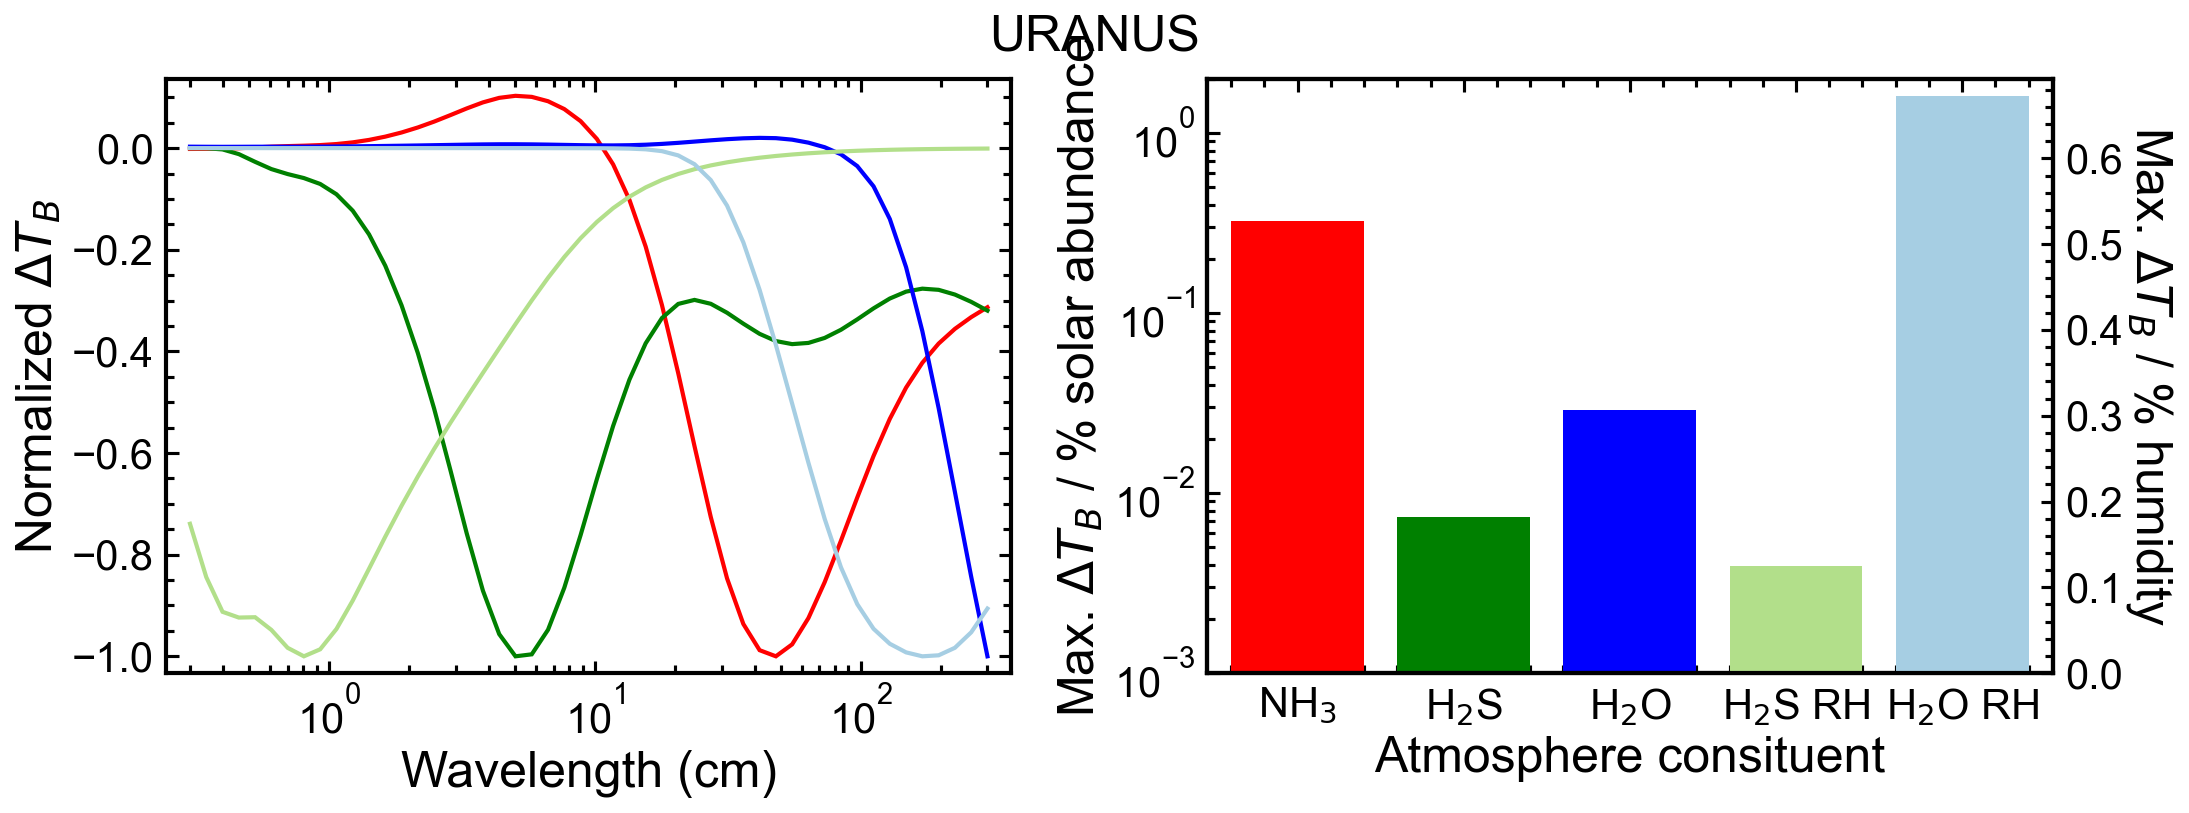

In [133]:
wave_cm = np.logspace(np.log10(0.3), np.log10(300), 50)  # One fn run takes 15s (30s for 100) 
freq_ghz = spc.c / (wave_cm * 1e-2) * 1e-9 
incang_deg = 0. 

step_gases = ['NH3', 'H2S', 'H2O']
rh_gases = ['H2S', 'H2O']
sg_psa = [1.48e-4, 2.89e-5, 1.07e-3]  # Solar ratios
label_dict = {'NH3': r'NH$_3$', 'H2S': r'H$_2$S','H2O': r'H$_2$O'}
paired_cmap = plt.get_cmap('Paired')
colors = ['r', 'g', 'b', paired_cmap(2), paired_cmap(0)]

p_grid = np.logspace(2, 10, 2500)
uranus_gravity = 8.87  # m/s2 
planet_radius = 25559  # km 

# Reference case
data_dir = eccm.__path__[0]
uranus_ro = np.loadtxt(os.path.join(data_dir, 'data/ro_profiles/uranus_voyager2_lindal1987.txt'), skiprows=3, delimiter=',')
uranus_pressure = uranus_ro[:, 0] * 1e2  # Pa
uranus_temperature = uranus_ro[:, 1]

gases = [eccm.GasInput('H2O', deep=35*gases1['O'], rh=0.35), 
         eccm.GasInput('NH3', deep=1*gases1['N'], rh=1.), 
         eccm.GasInput('H2S', deep=35*gases1['S'], rh=0.35), 
         eccm.GasInput('CH4', deep=50*gases1['C'], rh=1.), 
]

result  = eccm.run_eccm(p_grid, uranus_pressure, uranus_temperature, uranus_gravity,
                                                 gases=gases, bulk_h2=0.85, bulk_he=0.15,
                                                 latent_heat_update=True, force_reference_above_pressure=1.*spc.bar, 
                                                 use_compressibility=True)

pressure_grid = result['pressure']
temperature_grid = result['temperature']
altitude_grid = result['altitude']
x_h2o = result['gas_profiles']['H2O']
x_nh3 = result['gas_profiles']['NH3']
x_h2s = result['gas_profiles']['H2S']
x_ch4 = result['gas_profiles']['CH4']
x_ph3 = np.zeros(x_ch4.shape)
x_h2=0.85 * np.ones(x_ch4.shape)
x_he=0.15 * np.ones(x_ch4.shape)

a_h2osolid = result['aerosol_densities']['H2O']['solid']
a_h2oliquid = result['aerosol_densities']['H2O']['liquid']
a_nh3solid = result['aerosol_densities']['NH3']['solid']
a_nh3liquid = result['aerosol_densities']['NH3']['liquid']
a_h2ssolid = result['aerosol_densities']['H2S']['solid']
a_h2sliquid = result['aerosol_densities']['H2S']['liquid']
a_ch4solid = result['aerosol_densities']['CH4']['solid']
a_ch4liquid = result['aerosol_densities']['CH4']['liquid']
a_h2osolution = result['aerosol_densities']['H2O_NH3_SOLUTION']['liquid']
a_nh4sh = result['aerosol_densities']['NH4SH']['solid']


minloc = np.argmin(abs(pressure_grid / spc.bar - 1e-3))
maxloc = np.argmin(abs(pressure_grid / spc.bar - 1000e3))
slc = slice(maxloc, minloc, 3)
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
ref_spec = Tup 
this_jac_list = [] 

for j, sg in enumerate(tqdm(step_gases, desc='Deep ATM')):
    if sg == 'NH3': 
        use_deep_nh3 = 1*gases1['N'] + 1e-2 * sg_psa[0]
        use_deep_h2s = 35*gases1['S'] 
        use_deep_h2o = 35*gases1['O']
    elif sg == 'H2S': 
        use_deep_nh3 = 1*gases1['N'] 
        use_deep_h2s = 35*gases1['S'] + 1e-2 * sg_psa[1]
        use_deep_h2o = 35*gases1['O']
    else: 
        use_deep_nh3 = 1*gases1['N'] 
        use_deep_h2s = 35*gases1['S'] 
        use_deep_h2o = 35*gases1['O'] + 1e-2 * sg_psa[2]

    gases = [eccm.GasInput('H2O', deep=use_deep_h2o, rh=0.35), 
            eccm.GasInput('NH3', deep=use_deep_nh3, rh=1.), 
            eccm.GasInput('H2S', deep=use_deep_h2s, rh=0.35), 
            eccm.GasInput('CH4', deep=50*gases1['C'], rh=1.), 
        ]

    result  = eccm.run_eccm(p_grid, uranus_pressure, uranus_temperature, uranus_gravity,
                                                    gases=gases, bulk_h2=0.85, bulk_he=0.15,
                                                    latent_heat_update=True, force_reference_above_pressure=1.*spc.bar, 
                                                    use_compressibility=True)

    pressure_grid = result['pressure']
    temperature_grid = result['temperature']
    altitude_grid = result['altitude']
    x_h2o = result['gas_profiles']['H2O']
    x_nh3 = result['gas_profiles']['NH3']
    x_h2s = result['gas_profiles']['H2S']
    x_ch4 = result['gas_profiles']['CH4']
    x_ph3 = np.zeros(x_ch4.shape)
    x_h2=0.85 * np.ones(x_ch4.shape)
    x_he=0.15 * np.ones(x_ch4.shape)

    a_h2osolid = result['aerosol_densities']['H2O']['solid']
    a_h2oliquid = result['aerosol_densities']['H2O']['liquid']
    a_nh3solid = result['aerosol_densities']['NH3']['solid']
    a_nh3liquid = result['aerosol_densities']['NH3']['liquid']
    a_h2ssolid = result['aerosol_densities']['H2S']['solid']
    a_h2sliquid = result['aerosol_densities']['H2S']['liquid']
    a_ch4solid = result['aerosol_densities']['CH4']['solid']
    a_ch4liquid = result['aerosol_densities']['CH4']['liquid']
    a_h2osolution = result['aerosol_densities']['H2O_NH3_SOLUTION']['liquid']
    a_nh4sh = result['aerosol_densities']['NH4SH']['solid']

    full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
    this_jac = (Tup - ref_spec) / 1e-2 
    this_jac_list.append(this_jac.copy()) 

for j, rhg in enumerate(tqdm(rh_gases, desc='RH')):
    if rhg == 'H2S': 
        use_h2s_rh = 0.35 + 1e-2 
        use_h2o_rh = 0.35 
    else: 
        use_h2s_rh = 0.35 
        use_h2o_rh = 0.35 + 1e-2 

    gases = [eccm.GasInput('H2O', deep=35*gases1['O'], rh=use_h2o_rh), 
            eccm.GasInput('NH3', deep=1*gases1['N'], rh=1.), 
            eccm.GasInput('H2S', deep=35*gases1['S'], rh=use_h2s_rh), 
            eccm.GasInput('CH4', deep=50*gases1['C'], rh=1.), 
    ]

    result  = eccm.run_eccm(p_grid, uranus_pressure, uranus_temperature, uranus_gravity,
                                                    gases=gases, bulk_h2=0.85, bulk_he=0.15,
                                                    latent_heat_update=True, force_reference_above_pressure=1.*spc.bar, 
                                                    use_compressibility=True)

    pressure_grid = result['pressure']
    temperature_grid = result['temperature']
    altitude_grid = result['altitude']
    x_h2o = result['gas_profiles']['H2O']
    x_nh3 = result['gas_profiles']['NH3']
    x_h2s = result['gas_profiles']['H2S']
    x_ch4 = result['gas_profiles']['CH4']
    x_ph3 = np.zeros(x_ch4.shape)
    x_h2=0.85 * np.ones(x_ch4.shape)
    x_he=0.15 * np.ones(x_ch4.shape)

    a_h2osolid = result['aerosol_densities']['H2O']['solid']
    a_h2oliquid = result['aerosol_densities']['H2O']['liquid']
    a_nh3solid = result['aerosol_densities']['NH3']['solid']
    a_nh3liquid = result['aerosol_densities']['NH3']['liquid']
    a_h2ssolid = result['aerosol_densities']['H2S']['solid']
    a_h2sliquid = result['aerosol_densities']['H2S']['liquid']
    a_ch4solid = result['aerosol_densities']['CH4']['solid']
    a_ch4liquid = result['aerosol_densities']['CH4']['liquid']
    a_h2osolution = result['aerosol_densities']['H2O_NH3_SOLUTION']['liquid']
    a_nh4sh = result['aerosol_densities']['NH4SH']['solid']
        
    full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
    this_jac = (Tup - ref_spec) / 1e-2 
    this_jac_list.append(this_jac.copy()) 

fig, axs = plt.subplots(1, 2, figsize=(15, 6))
tax = axs[1].twinx()
for j, tj in enumerate(this_jac_list): 
    if j < 3: 
        use_label = label_dict[step_gases[j]]
        axs[1].bar(use_label, np.max(abs(tj)) * 1e-2 , color=colors[j], label=use_label)
    else:
        use_label = label_dict[rh_gases[j - 3]] + ' RH' 
        tax.bar(use_label, np.max(abs(tj)) * 1e-2 , color=colors[j], label=use_label)
    axs[0].semilogx(wave_cm, tj / np.max(abs(tj)), color=colors[j], label=use_label)
        
axs[0].set_xlabel('Wavelength (cm)')
axs[0].set_ylabel(r'Normalized $\Delta T_B$')
axs[1].set_xlabel('Atmosphere consituent')
axs[1].set_ylabel(r'Max. $\Delta T_B$ / % solar abundance')
tax.set_ylabel(r'Max. $\Delta T_B$ / % humidity', rotation=-90, labelpad=25)
# axs[0].legend()
axs[1].set_yscale('log')
axs[1].set_ylim(1e-3, 2)
fig.suptitle('URANUS', y=0.92)

fig.tight_layout()    
fig.savefig('uranus_dTB.pdf')
    

## Model perturbation tests - Saturn
### Deep water abundance  

<>:220: SyntaxWarning: invalid escape sequence '\D'
<>:221: SyntaxWarning: invalid escape sequence '\D'
<>:222: SyntaxWarning: invalid escape sequence '\D'
<>:220: SyntaxWarning: invalid escape sequence '\D'
<>:221: SyntaxWarning: invalid escape sequence '\D'
<>:222: SyntaxWarning: invalid escape sequence '\D'
/var/folders/zg/yqp2bsw569ngkkjdlpj0b5cw0000gq/T/ipykernel_41272/2893305206.py:220: SyntaxWarning: invalid escape sequence '\D'
  ax1.set_ylabel('$\Delta$ T$_B$ (Kelvins)')
/var/folders/zg/yqp2bsw569ngkkjdlpj0b5cw0000gq/T/ipykernel_41272/2893305206.py:221: SyntaxWarning: invalid escape sequence '\D'
  ax2.set_ylabel('$\Delta$ R(50$^\circ$) %')
/var/folders/zg/yqp2bsw569ngkkjdlpj0b5cw0000gq/T/ipykernel_41272/2893305206.py:222: SyntaxWarning: invalid escape sequence '\D'
  axins.set_ylabel('$\Delta$ T$_B$')


/var/folders/zg/yqp2bsw569ngkkjdlpj0b5cw0000gq/T/ipykernel_41272/2893305206.py:233: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/zg/yqp2bsw569ngkkjdlpj0b5cw0000gq/T/ipykernel_41272/2893305206.py:233: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


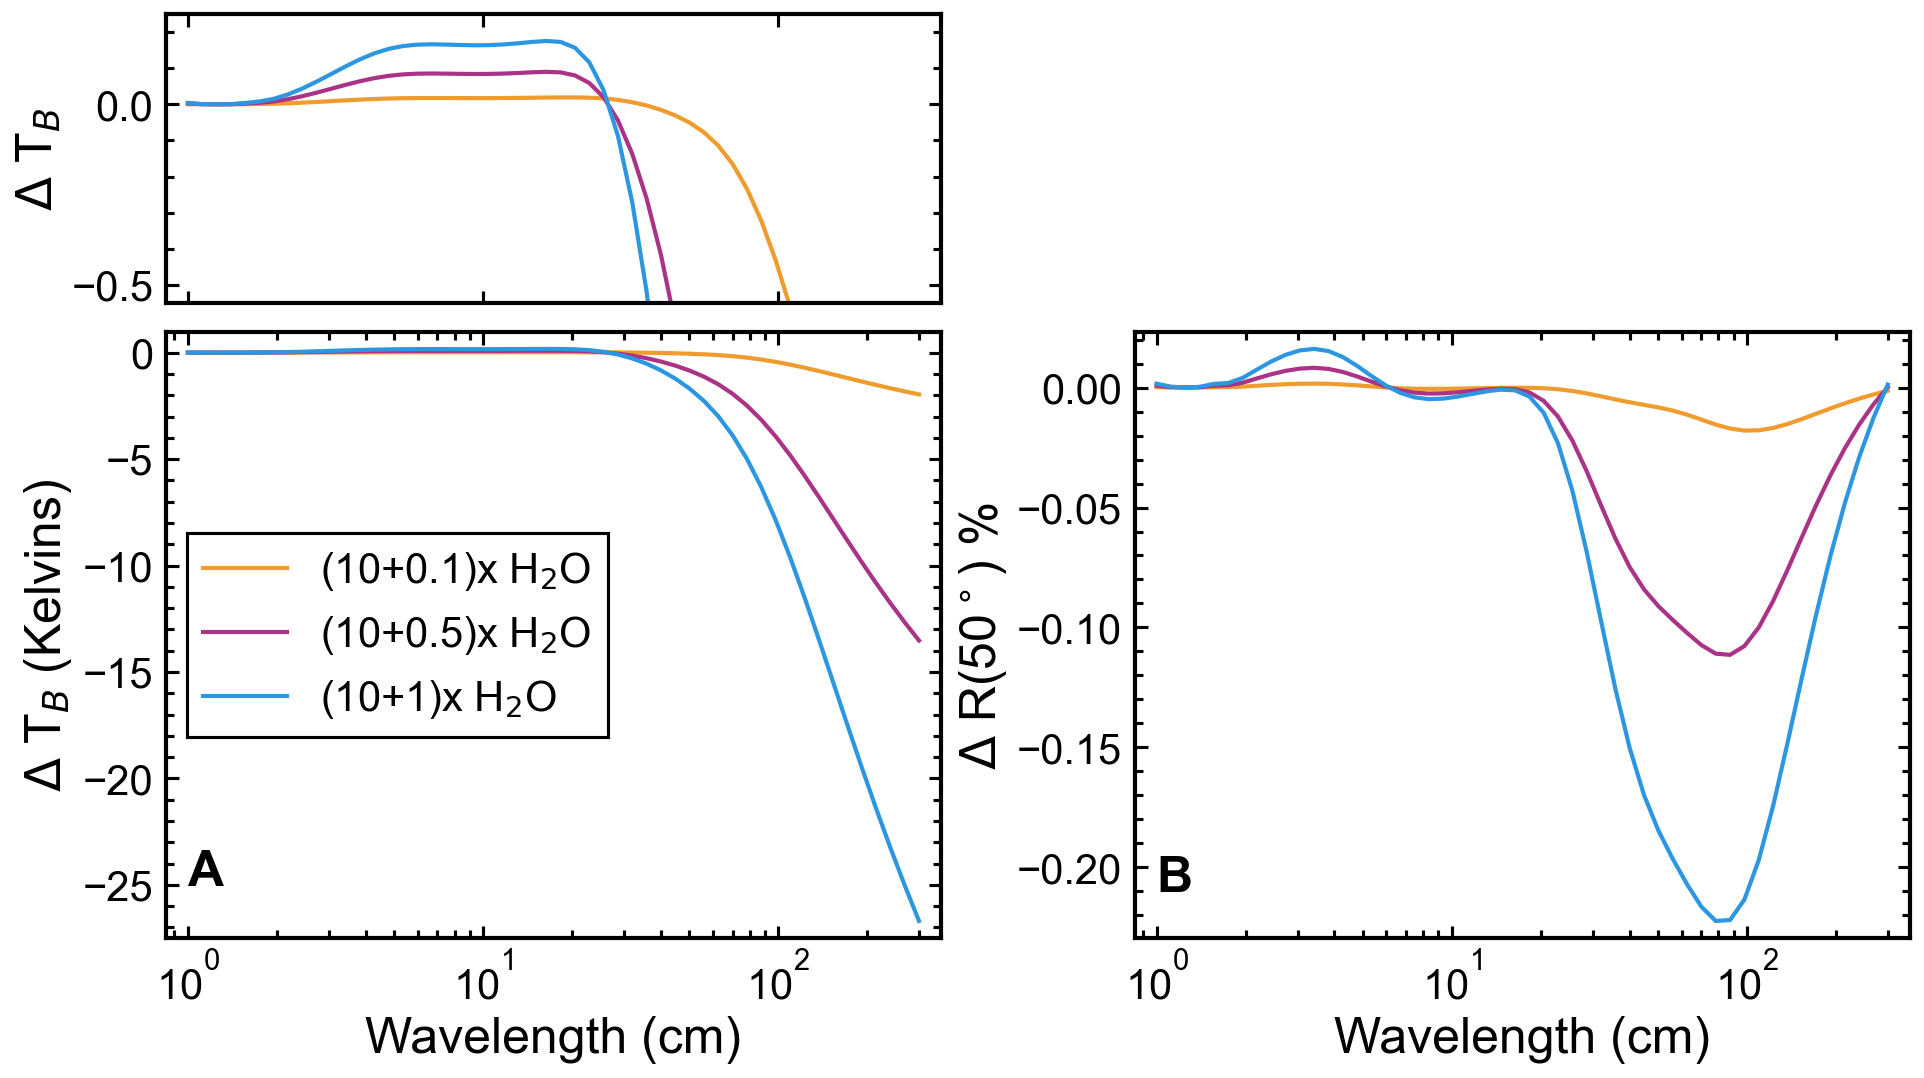

In [ ]:
p_grid = np.logspace(2, 10, 2500)
saturn_gravity = 10.44  # m/s2 
planet_radius = 60268  # Saturn
freq_ghz = 3e-1 / np.logspace(np.log10(1e-2), np.log10(3), 52)
wave_cm = spc.c / (freq_ghz * 1e9) * 1e2 

# Load RO profile 
data_dir = eccm.__path__[0]
saturn_ro = np.loadtxt(os.path.join(data_dir, 'data/ro_profiles/saturn_cassini_schinder2011.txt'), skiprows=3, delimiter=',')
saturn_pressure = saturn_ro[:, 0] * 1e2  # Pa
saturn_temperature = saturn_ro[:, 1]

gases1 = eccm.solar_concentration() 
gases = [eccm.GasInput('H2O', deep=10*gases1['O'], rh=0.7), 
         eccm.GasInput('NH3', deep=3*gases1['N'], rh=0.7), 
         eccm.GasInput('H2S', deep=10*gases1['S'], rh=1.), 
         eccm.GasInput('CH4', deep=10*gases1['C'], rh=1.), 
         ]

result  = eccm.run_eccm(p_grid, saturn_pressure, saturn_temperature, saturn_gravity,
                                                 gases=gases, bulk_h2=0.88, bulk_he=0.12,
                                                 latent_heat_update=True, force_reference_above_pressure=1.*spc.bar, 
                                                 use_compressibility=True)

pressure_grid = result['pressure']
temperature_grid = result['temperature']
altitude_grid = result['altitude']
x_h2o = result['gas_profiles']['H2O']
x_nh3 = result['gas_profiles']['NH3']
x_h2s = result['gas_profiles']['H2S']
x_ch4 = result['gas_profiles']['CH4']
x_ph3 = np.zeros(x_ch4.shape)
x_h2=0.88 * np.ones(x_ch4.shape)
x_he=0.12 * np.ones(x_ch4.shape)

a_h2osolid = result['aerosol_densities']['H2O']['solid']
a_h2oliquid = result['aerosol_densities']['H2O']['liquid']
a_nh3solid = result['aerosol_densities']['NH3']['solid']
a_nh3liquid = result['aerosol_densities']['NH3']['liquid']
a_h2ssolid = result['aerosol_densities']['H2S']['solid']
a_h2sliquid = result['aerosol_densities']['H2S']['liquid']
a_ch4solid = result['aerosol_densities']['CH4']['solid']
a_ch4liquid = result['aerosol_densities']['CH4']['liquid']
a_h2osolution = result['aerosol_densities']['H2O_NH3_SOLUTION']['liquid']
a_nh4sh = result['aerosol_densities']['NH4SH']['solid']

incang_deg = 0. 
# Don't need to use the full atmosphere grid
minloc = np.argmin(abs(pressure_grid / spc.bar - 1e-3))
maxloc = np.argmin(abs(pressure_grid / spc.bar - 10000e3))
slc = slice(maxloc, minloc, 3)
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec1 = Tup 
incang_deg = 50. 
full_tau, _, _, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec2 = Tup 
R50 = (spec1 - spec2) / spec1 * 1e2 
ref_spec = spec1
ref_50 = R50 

# Next 
gases = [eccm.GasInput('H2O', deep=10.1*gases1['O'], rh=0.7), 
         eccm.GasInput('NH3', deep=3*gases1['N'], rh=0.7), 
         eccm.GasInput('H2S', deep=10*gases1['S'], rh=1.), 
         eccm.GasInput('CH4', deep=10*gases1['C'], rh=1.), 
         ]

result  = eccm.run_eccm(p_grid, saturn_pressure, saturn_temperature, saturn_gravity,
                                                 gases=gases, bulk_h2=0.88, bulk_he=0.12,
                                                 latent_heat_update=True, force_reference_above_pressure=1.*spc.bar, 
                                                 use_compressibility=True)

pressure_grid = result['pressure']
temperature_grid = result['temperature']
altitude_grid = result['altitude']
x_h2o = result['gas_profiles']['H2O']
x_nh3 = result['gas_profiles']['NH3']
x_h2s = result['gas_profiles']['H2S']
x_ch4 = result['gas_profiles']['CH4']
x_ph3 = np.zeros(x_ch4.shape)
x_h2=0.88 * np.ones(x_ch4.shape)
x_he=0.12 * np.ones(x_ch4.shape)

a_h2osolid = result['aerosol_densities']['H2O']['solid']
a_h2oliquid = result['aerosol_densities']['H2O']['liquid']
a_nh3solid = result['aerosol_densities']['NH3']['solid']
a_nh3liquid = result['aerosol_densities']['NH3']['liquid']
a_h2ssolid = result['aerosol_densities']['H2S']['solid']
a_h2sliquid = result['aerosol_densities']['H2S']['liquid']
a_ch4solid = result['aerosol_densities']['CH4']['solid']
a_ch4liquid = result['aerosol_densities']['CH4']['liquid']
a_h2osolution = result['aerosol_densities']['H2O_NH3_SOLUTION']['liquid']
a_nh4sh = result['aerosol_densities']['NH4SH']['solid']

incang_deg = 0. 
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec1 = Tup 
incang_deg = 50. 
full_tau, _, _, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec2 = Tup 
R50 = (spec1 - spec2) / spec1 * 1e2 
spec_1 = spec1 
R50_1 = R50

# Next 
gases = [eccm.GasInput('H2O', deep=10.5*gases1['O'], rh=0.7), 
         eccm.GasInput('NH3', deep=3*gases1['N'], rh=0.7), 
         eccm.GasInput('H2S', deep=10*gases1['S'], rh=1.), 
         eccm.GasInput('CH4', deep=10*gases1['C'], rh=1.), 
         ]

result  = eccm.run_eccm(p_grid, saturn_pressure, saturn_temperature, saturn_gravity,
                                                 gases=gases, bulk_h2=0.88, bulk_he=0.12,
                                                 latent_heat_update=True, force_reference_above_pressure=1.*spc.bar, 
                                                 use_compressibility=True)

pressure_grid = result['pressure']
temperature_grid = result['temperature']
altitude_grid = result['altitude']
x_h2o = result['gas_profiles']['H2O']
x_nh3 = result['gas_profiles']['NH3']
x_h2s = result['gas_profiles']['H2S']
x_ch4 = result['gas_profiles']['CH4']
x_ph3 = np.zeros(x_ch4.shape)
x_h2=0.88 * np.ones(x_ch4.shape)
x_he=0.12 * np.ones(x_ch4.shape)

a_h2osolid = result['aerosol_densities']['H2O']['solid']
a_h2oliquid = result['aerosol_densities']['H2O']['liquid']
a_nh3solid = result['aerosol_densities']['NH3']['solid']
a_nh3liquid = result['aerosol_densities']['NH3']['liquid']
a_h2ssolid = result['aerosol_densities']['H2S']['solid']
a_h2sliquid = result['aerosol_densities']['H2S']['liquid']
a_ch4solid = result['aerosol_densities']['CH4']['solid']
a_ch4liquid = result['aerosol_densities']['CH4']['liquid']
a_h2osolution = result['aerosol_densities']['H2O_NH3_SOLUTION']['liquid']
a_nh4sh = result['aerosol_densities']['NH4SH']['solid']

incang_deg = 0. 
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec1 = Tup 
incang_deg = 50. 
full_tau, _, _, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec2 = Tup 
R50 = (spec1 - spec2) / spec1 * 1e2 
spec_2 = spec1 
R50_2 = R50 

# Next 
gases = [eccm.GasInput('H2O', deep=11*gases1['O'], rh=0.7), 
         eccm.GasInput('NH3', deep=3*gases1['N'], rh=0.7), 
         eccm.GasInput('H2S', deep=10*gases1['S'], rh=1.), 
         eccm.GasInput('CH4', deep=10*gases1['C'], rh=1.), 
         ]

result  = eccm.run_eccm(p_grid, saturn_pressure, saturn_temperature, saturn_gravity,
                                                 gases=gases, bulk_h2=0.88, bulk_he=0.12,
                                                 latent_heat_update=True, force_reference_above_pressure=1.*spc.bar, 
                                                 use_compressibility=True)

pressure_grid = result['pressure']
temperature_grid = result['temperature']
altitude_grid = result['altitude']
x_h2o = result['gas_profiles']['H2O']
x_nh3 = result['gas_profiles']['NH3']
x_h2s = result['gas_profiles']['H2S']
x_ch4 = result['gas_profiles']['CH4']
x_ph3 = np.zeros(x_ch4.shape)
x_h2=0.88 * np.ones(x_ch4.shape)
x_he=0.12 * np.ones(x_ch4.shape)

a_h2osolid = result['aerosol_densities']['H2O']['solid']
a_h2oliquid = result['aerosol_densities']['H2O']['liquid']
a_nh3solid = result['aerosol_densities']['NH3']['solid']
a_nh3liquid = result['aerosol_densities']['NH3']['liquid']
a_h2ssolid = result['aerosol_densities']['H2S']['solid']
a_h2sliquid = result['aerosol_densities']['H2S']['liquid']
a_ch4solid = result['aerosol_densities']['CH4']['solid']
a_ch4liquid = result['aerosol_densities']['CH4']['liquid']
a_h2osolution = result['aerosol_densities']['H2O_NH3_SOLUTION']['liquid']
a_nh4sh = result['aerosol_densities']['NH4SH']['solid']

incang_deg = 0. 
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec1 = Tup 
incang_deg = 50. 
full_tau, _, _, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec2 = Tup 
R50 = (spec1 - spec2) / spec1 * 1e2 
spec_3 = spec1 
R50_3 = R50

fig = plt.figure(figsize=(15, 8), constrained_layout=True)
gs = fig.add_gridspec(nrows=3, ncols=2, hspace=0.1, wspace=0.25)
ax1 = fig.add_subplot(gs[1:, 0])
ax2 = fig.add_subplot(gs[1:, 1])
axins = fig.add_subplot(gs[0, 0])

colors = [
    (240, 155, 45),   
    (170, 50, 135),   
    (45, 150, 225),   
]
colors = [(r/255, g/255, b/255) for r, g, b in colors]

ax1.plot(wave_cm, spec_1-ref_spec, label='(10+0.1)x H$_2$O', color=colors[0], lw=2)
ax2.plot(wave_cm, R50_1-ref_50, lw=2, color=colors[0])
axins.plot(wave_cm, spec_1-ref_spec, lw=2, color=colors[0])

ax1.plot(wave_cm, spec_2-ref_spec, label='(10+0.5)x H$_2$O', color=colors[1], lw=2)
ax2.plot(wave_cm, R50_2-ref_50, color=colors[1], lw=2)
axins.plot(wave_cm, spec_2-ref_spec, color=colors[1], lw=2)


ax1.plot(wave_cm, spec_3-ref_spec, label='(10+1)x H$_2$O', color=colors[2], lw=2)
ax2.plot(wave_cm, R50_3-ref_50, color=colors[2], lw=2)
axins.plot(wave_cm, spec_3-ref_spec, color=colors[2], lw=2)

ax1.set_xlabel('Wavelength (cm)')
ax2.set_xlabel('Wavelength (cm)')
ax1.set_ylabel(r'$\Delta$ T$_B$ (Kelvins)')
ax2.set_ylabel(r'$\Delta$ R(50$^\circ$) %')
axins.set_ylabel(r'$\Delta$ T$_B$')

ax1.legend(loc='center left') 
ax1.set_xscale('log')
ax2.set_xscale('log')
axins.set_xscale('log')
axins.xaxis.minorticks_off()
axins.tick_params(labelbottom=False)
axins.set_ylim(-0.55, 0.25)
ax1.text(1, -25, 'A', weight='bold', fontsize=24)
ax2.text(1, -0.21, 'B', weight='bold', fontsize=24)
fig.tight_layout()
fig.savefig('saturn_water.pdf')

### Deep NH3 abundance  

<>:222: SyntaxWarning: invalid escape sequence '\D'
<>:223: SyntaxWarning: invalid escape sequence '\D'
<>:224: SyntaxWarning: invalid escape sequence '\D'
<>:222: SyntaxWarning: invalid escape sequence '\D'
<>:223: SyntaxWarning: invalid escape sequence '\D'
<>:224: SyntaxWarning: invalid escape sequence '\D'
/var/folders/zg/yqp2bsw569ngkkjdlpj0b5cw0000gq/T/ipykernel_41272/4044754327.py:222: SyntaxWarning: invalid escape sequence '\D'
  ax1.set_ylabel('$\Delta$ T$_B$ (Kelvins)')
/var/folders/zg/yqp2bsw569ngkkjdlpj0b5cw0000gq/T/ipykernel_41272/4044754327.py:223: SyntaxWarning: invalid escape sequence '\D'
  ax2.set_ylabel('$\Delta$ R(50$^\circ$) %')
/var/folders/zg/yqp2bsw569ngkkjdlpj0b5cw0000gq/T/ipykernel_41272/4044754327.py:224: SyntaxWarning: invalid escape sequence '\D'
  axins.set_ylabel('$\Delta$ T$_B$')


/var/folders/zg/yqp2bsw569ngkkjdlpj0b5cw0000gq/T/ipykernel_41272/4044754327.py:235: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/zg/yqp2bsw569ngkkjdlpj0b5cw0000gq/T/ipykernel_41272/4044754327.py:235: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


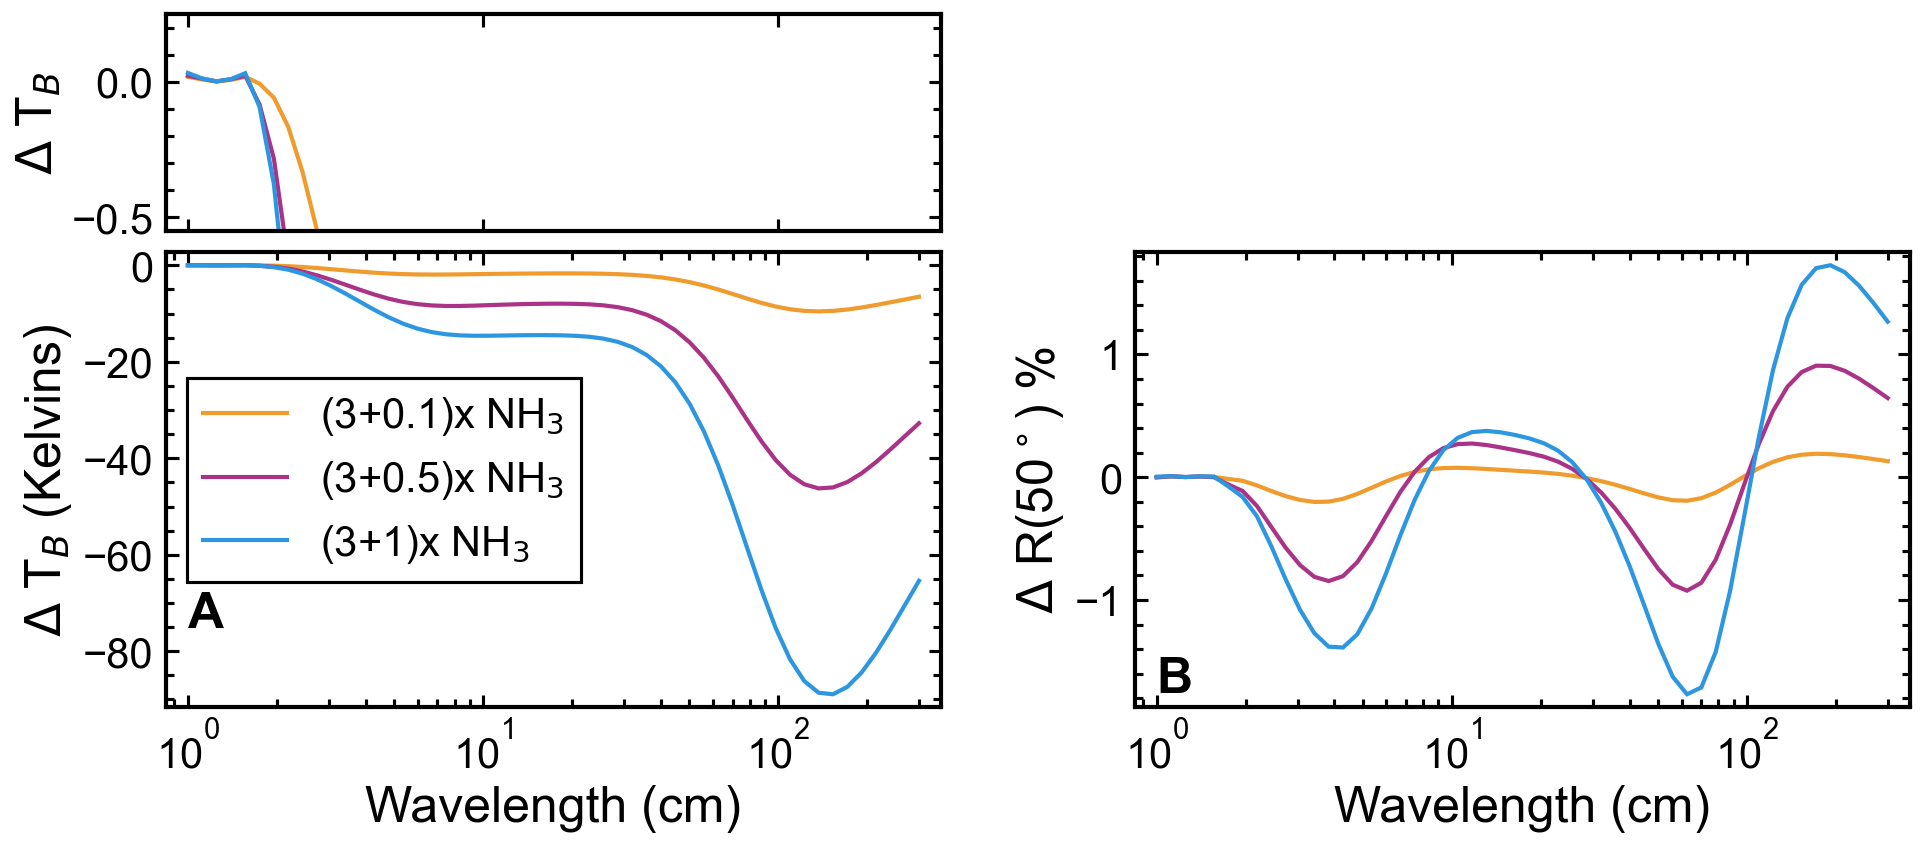

In [ ]:
p_grid = np.logspace(2, 10, 2500)
saturn_gravity = 10.44  # m/s2 
planet_radius = 60268  # Saturn
freq_ghz = 3e-1 / np.logspace(np.log10(1e-2), np.log10(3), 52)
wave_cm = spc.c / (freq_ghz * 1e9) * 1e2 

# Load RO profile 
data_dir = eccm.__path__[0]
saturn_ro = np.loadtxt(os.path.join(data_dir, 'data/ro_profiles/saturn_cassini_schinder2011.txt'), skiprows=3, delimiter=',')
saturn_pressure = saturn_ro[:, 0] * 1e2  # Pa
saturn_temperature = saturn_ro[:, 1]

gases1 = eccm.solar_concentration() 
gases = [eccm.GasInput('H2O', deep=0*gases1['O'], rh=0.7), 
         eccm.GasInput('NH3', deep=3*gases1['N'], rh=0.7), 
         eccm.GasInput('H2S', deep=10*gases1['S'], rh=1.), 
         eccm.GasInput('CH4', deep=10*gases1['C'], rh=1.), 
         ]

result  = eccm.run_eccm(p_grid, saturn_pressure, saturn_temperature, saturn_gravity,
                                                 gases=gases, bulk_h2=0.88, bulk_he=0.12,
                                                 latent_heat_update=True, force_reference_above_pressure=1.*spc.bar, 
                                                 use_compressibility=True)

pressure_grid = result['pressure']
temperature_grid = result['temperature']
altitude_grid = result['altitude']
x_h2o = result['gas_profiles']['H2O']
x_nh3 = result['gas_profiles']['NH3']
x_h2s = result['gas_profiles']['H2S']
x_ch4 = result['gas_profiles']['CH4']
x_ph3 = np.zeros(x_ch4.shape)
x_h2=0.88 * np.ones(x_ch4.shape)
x_he=0.12 * np.ones(x_ch4.shape)

a_h2osolid = result['aerosol_densities']['H2O']['solid']
a_h2oliquid = result['aerosol_densities']['H2O']['liquid']
a_nh3solid = result['aerosol_densities']['NH3']['solid']
a_nh3liquid = result['aerosol_densities']['NH3']['liquid']
a_h2ssolid = result['aerosol_densities']['H2S']['solid']
a_h2sliquid = result['aerosol_densities']['H2S']['liquid']
a_ch4solid = result['aerosol_densities']['CH4']['solid']
a_ch4liquid = result['aerosol_densities']['CH4']['liquid']
a_h2osolution = result['aerosol_densities']['H2O_NH3_SOLUTION']['liquid']
a_nh4sh = result['aerosol_densities']['NH4SH']['solid']

incang_deg = 0. 
# Don't need to use the full atmosphere grid
minloc = np.argmin(abs(pressure_grid / spc.bar - 1e-3))
maxloc = np.argmin(abs(pressure_grid / spc.bar - 10000e3))
slc = slice(maxloc, minloc, 3)
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec1 = Tup 
incang_deg = 50. 
full_tau, _, _, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec2 = Tup 
R50 = (spec1 - spec2) / spec1 * 1e2 
ref_spec = spec1
ref_50 = R50 

gases = [eccm.GasInput('H2O', deep=10*gases1['O'], rh=0.7), 
         eccm.GasInput('NH3', deep=3.1*gases1['N'], rh=0.7), 
         eccm.GasInput('H2S', deep=10*gases1['S'], rh=1.), 
         eccm.GasInput('CH4', deep=10*gases1['C'], rh=1.), 
         ]

result  = eccm.run_eccm(p_grid, saturn_pressure, saturn_temperature, saturn_gravity,
                                                 gases=gases, bulk_h2=0.88, bulk_he=0.12,
                                                 latent_heat_update=True, force_reference_above_pressure=1.*spc.bar, 
                                                 use_compressibility=True)

pressure_grid = result['pressure']
temperature_grid = result['temperature']
altitude_grid = result['altitude']
x_h2o = result['gas_profiles']['H2O']
x_nh3 = result['gas_profiles']['NH3']
x_h2s = result['gas_profiles']['H2S']
x_ch4 = result['gas_profiles']['CH4']
x_ph3 = np.zeros(x_ch4.shape)
x_h2=0.88 * np.ones(x_ch4.shape)
x_he=0.12 * np.ones(x_ch4.shape)

a_h2osolid = result['aerosol_densities']['H2O']['solid']
a_h2oliquid = result['aerosol_densities']['H2O']['liquid']
a_nh3solid = result['aerosol_densities']['NH3']['solid']
a_nh3liquid = result['aerosol_densities']['NH3']['liquid']
a_h2ssolid = result['aerosol_densities']['H2S']['solid']
a_h2sliquid = result['aerosol_densities']['H2S']['liquid']
a_ch4solid = result['aerosol_densities']['CH4']['solid']
a_ch4liquid = result['aerosol_densities']['CH4']['liquid']
a_h2osolution = result['aerosol_densities']['H2O_NH3_SOLUTION']['liquid']
a_nh4sh = result['aerosol_densities']['NH4SH']['solid']

incang_deg = 0. 
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec1 = Tup 
incang_deg = 50. 
full_tau, _, _, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec2 = Tup 
R50 = (spec1 - spec2) / spec1 * 1e2 
spec_1 = spec1 
R50_1 = R50



# Next 
gases = [eccm.GasInput('H2O', deep=10*gases1['O'], rh=0.7), 
         eccm.GasInput('NH3', deep=3.5*gases1['N'], rh=0.7), 
         eccm.GasInput('H2S', deep=10*gases1['S'], rh=1.), 
         eccm.GasInput('CH4', deep=10*gases1['C'], rh=1.), 
         ]

result  = eccm.run_eccm(p_grid, saturn_pressure, saturn_temperature, saturn_gravity,
                                                 gases=gases, bulk_h2=0.88, bulk_he=0.12,
                                                 latent_heat_update=True, force_reference_above_pressure=1.*spc.bar, 
                                                 use_compressibility=True)

pressure_grid = result['pressure']
temperature_grid = result['temperature']
altitude_grid = result['altitude']
x_h2o = result['gas_profiles']['H2O']
x_nh3 = result['gas_profiles']['NH3']
x_h2s = result['gas_profiles']['H2S']
x_ch4 = result['gas_profiles']['CH4']
x_ph3 = np.zeros(x_ch4.shape)
x_h2=0.88 * np.ones(x_ch4.shape)
x_he=0.12 * np.ones(x_ch4.shape)

a_h2osolid = result['aerosol_densities']['H2O']['solid']
a_h2oliquid = result['aerosol_densities']['H2O']['liquid']
a_nh3solid = result['aerosol_densities']['NH3']['solid']
a_nh3liquid = result['aerosol_densities']['NH3']['liquid']
a_h2ssolid = result['aerosol_densities']['H2S']['solid']
a_h2sliquid = result['aerosol_densities']['H2S']['liquid']
a_ch4solid = result['aerosol_densities']['CH4']['solid']
a_ch4liquid = result['aerosol_densities']['CH4']['liquid']
a_h2osolution = result['aerosol_densities']['H2O_NH3_SOLUTION']['liquid']
a_nh4sh = result['aerosol_densities']['NH4SH']['solid']

incang_deg = 0. 
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec1 = Tup 
incang_deg = 50. 
full_tau, _, _, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec2 = Tup 
R50 = (spec1 - spec2) / spec1 * 1e2 
spec_2 = spec1 
R50_2 = R50

# Next 
gases = [eccm.GasInput('H2O', deep=10*gases1['O'], rh=0.7), 
         eccm.GasInput('NH3', deep=4*gases1['N'], rh=0.7), 
         eccm.GasInput('H2S', deep=10*gases1['S'], rh=1.), 
         eccm.GasInput('CH4', deep=10*gases1['C'], rh=1.), 
         ]

result  = eccm.run_eccm(p_grid, saturn_pressure, saturn_temperature, saturn_gravity,
                                                 gases=gases, bulk_h2=0.88, bulk_he=0.12,
                                                 latent_heat_update=True, force_reference_above_pressure=1.*spc.bar, 
                                                 use_compressibility=True)

pressure_grid = result['pressure']
temperature_grid = result['temperature']
altitude_grid = result['altitude']
x_h2o = result['gas_profiles']['H2O']
x_nh3 = result['gas_profiles']['NH3']
x_h2s = result['gas_profiles']['H2S']
x_ch4 = result['gas_profiles']['CH4']
x_ph3 = np.zeros(x_ch4.shape)
x_h2=0.88 * np.ones(x_ch4.shape)
x_he=0.12 * np.ones(x_ch4.shape)

a_h2osolid = result['aerosol_densities']['H2O']['solid']
a_h2oliquid = result['aerosol_densities']['H2O']['liquid']
a_nh3solid = result['aerosol_densities']['NH3']['solid']
a_nh3liquid = result['aerosol_densities']['NH3']['liquid']
a_h2ssolid = result['aerosol_densities']['H2S']['solid']
a_h2sliquid = result['aerosol_densities']['H2S']['liquid']
a_ch4solid = result['aerosol_densities']['CH4']['solid']
a_ch4liquid = result['aerosol_densities']['CH4']['liquid']
a_h2osolution = result['aerosol_densities']['H2O_NH3_SOLUTION']['liquid']
a_nh4sh = result['aerosol_densities']['NH4SH']['solid']

incang_deg = 0. 
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec1 = Tup 
incang_deg = 50. 
full_tau, _, _, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec2 = Tup 
R50 = (spec1 - spec2) / spec1 * 1e2 
spec_3 = spec1 
R50_3 = R50

fig = plt.figure(figsize=(15, 8))
gs = fig.add_gridspec(nrows=3, ncols=2, hspace=0.1, wspace=0.25)
ax1 = fig.add_subplot(gs[1:, 0])
ax2 = fig.add_subplot(gs[1:, 1])
axins = fig.add_subplot(gs[0, 0])

colors = [
    (240, 155, 45),   
    (170, 50, 135),   
    (45, 150, 225),   
]
colors = [(r/255, g/255, b/255) for r, g, b in colors]

ax1.plot(wave_cm, spec_1-ref_spec, label='(3+0.1)x NH$_3$', lw=2,color=colors[0])
ax2.plot(wave_cm, R50_1-ref_50, lw=2, color=colors[0])
axins.plot(wave_cm, spec_1-ref_spec, lw=2, color=colors[0])

ax1.plot(wave_cm, spec_2-ref_spec, label='(3+0.5)x NH$_3$', color=colors[1], lw=2)
ax2.plot(wave_cm, R50_2-ref_50, color=colors[1], lw=2)
axins.plot(wave_cm, spec_2-ref_spec, color=colors[1], lw=2)


ax1.plot(wave_cm, spec_3-ref_spec, label='(3+1)x NH$_3$', color=colors[2], lw=2)
ax2.plot(wave_cm, R50_3-ref_50, color=colors[2], lw=2)
axins.plot(wave_cm, spec_3-ref_spec, color=colors[2], lw=2)

ax1.set_xlabel('Wavelength (cm)')
ax2.set_xlabel('Wavelength (cm)')
ax1.set_ylabel(r'$\Delta$ T$_B$ (Kelvins)')
ax2.set_ylabel(r'$\Delta$ R(50$^\circ$) %')
axins.set_ylabel(r'$\Delta$ T$_B$')

ax1.legend(loc='center left') 
ax1.set_xscale('log')
ax2.set_xscale('log')
axins.set_xscale('log')
axins.xaxis.minorticks_off()
axins.tick_params(labelbottom=False)
axins.set_ylim(-5.5, 0.25)
ax1.text(1, -85, 'C', weight='bold', fontsize=24)
ax2.text(1, -1.5, 'D', weight='bold', fontsize=24)
fig.tight_layout()
fig.savefig('saturn_ammonia.pdf')

## Uranus 
### Deep water abundance

/var/folders/zg/yqp2bsw569ngkkjdlpj0b5cw0000gq/T/ipykernel_41272/3940416884.py:236: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/zg/yqp2bsw569ngkkjdlpj0b5cw0000gq/T/ipykernel_41272/3940416884.py:236: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


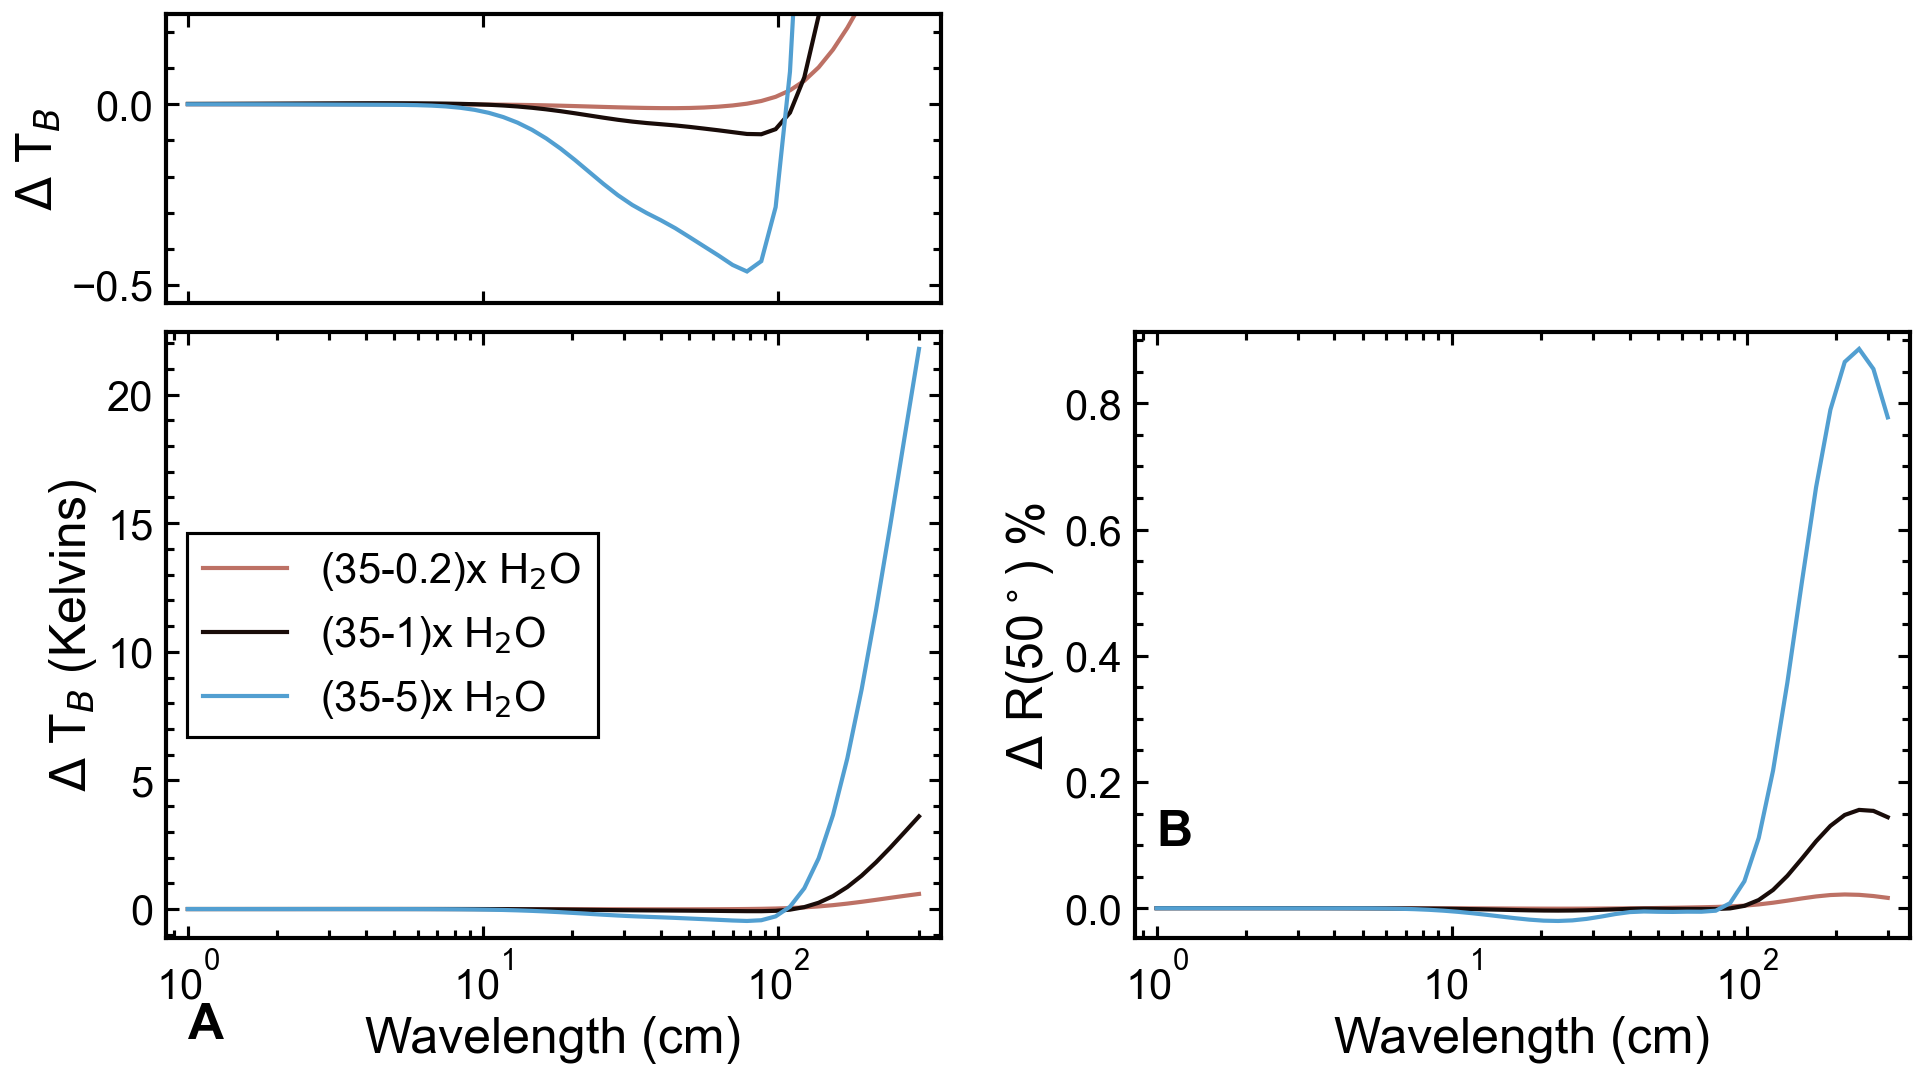

In [ ]:
p_grid = np.logspace(2, 9, 2500)
uranus_gravity = 8.69  # m/s2 
planet_radius = 25559  
freq_ghz = 3e-1 / np.logspace(np.log10(1e-2), np.log10(3), 52)
wave_cm = spc.c / (freq_ghz * 1e9) * 1e2 

# Load RO profile 
data_dir = eccm.__path__[0]
uranus_ro = np.loadtxt(os.path.join(data_dir, 'data/ro_profiles/uranus_voyager2_lindal1987.txt'), skiprows=3, delimiter=',')
uranus_pressure = uranus_ro[:, 0] * 1e2  # Pa
uranus_temperature = uranus_ro[:, 1]

# Baseline
gases1 = eccm.solar_concentration() 
gases = [eccm.GasInput('H2O', deep=35*gases1['O'], rh=0.35), 
         eccm.GasInput('NH3', deep=1*gases1['N'], rh=1.), 
         eccm.GasInput('H2S', deep=35*gases1['S'], rh=0.35), 
         eccm.GasInput('CH4', deep=50*gases1['C'], rh=1.), 
]

result  = eccm.run_eccm(p_grid, uranus_pressure, uranus_temperature, uranus_gravity,
                                                 gases=gases, bulk_h2=0.85, bulk_he=0.15,
                                                 latent_heat_update=True, force_reference_above_pressure=1.*spc.bar, 
                                                 use_compressibility=True)

pressure_grid = result['pressure']
temperature_grid = result['temperature']
altitude_grid = result['altitude']
x_h2o = result['gas_profiles']['H2O']
x_nh3 = result['gas_profiles']['NH3']
x_h2s = result['gas_profiles']['H2S']
x_ch4 = result['gas_profiles']['CH4']
x_ph3 = np.zeros(x_ch4.shape)
x_h2=0.85 * np.ones(x_ch4.shape)
x_he=0.15 * np.ones(x_ch4.shape)

a_h2osolid = result['aerosol_densities']['H2O']['solid']
a_h2oliquid = result['aerosol_densities']['H2O']['liquid']
a_nh3solid = result['aerosol_densities']['NH3']['solid']
a_nh3liquid = result['aerosol_densities']['NH3']['liquid']
a_h2ssolid = result['aerosol_densities']['H2S']['solid']
a_h2sliquid = result['aerosol_densities']['H2S']['liquid']
a_ch4solid = result['aerosol_densities']['CH4']['solid']
a_ch4liquid = result['aerosol_densities']['CH4']['liquid']
a_h2osolution = result['aerosol_densities']['H2O_NH3_SOLUTION']['liquid']
a_nh4sh = result['aerosol_densities']['NH4SH']['solid']

incang_deg = 0. 
# Don't need to use the full atmosphere grid
minloc = np.argmin(abs(pressure_grid / spc.bar - 1e-3))
maxloc = np.argmin(abs(pressure_grid / spc.bar - 1000e3))
slc = slice(maxloc, minloc, 3)
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec1 = Tup 
incang_deg = 50. 
full_tau, _, _, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec2 = Tup 
R50 = (spec1 - spec2) / spec1 * 1e2 
ref_spec = spec1
ref_50 = R50 

gases = [eccm.GasInput('H2O', deep=34.8*gases1['O'], rh=0.35), 
         eccm.GasInput('NH3', deep=1*gases1['N'], rh=1.), 
         eccm.GasInput('H2S', deep=35*gases1['S'], rh=0.35), 
         eccm.GasInput('CH4', deep=50*gases1['C'], rh=1.), 
]

result  = eccm.run_eccm(p_grid, uranus_pressure, uranus_temperature, uranus_gravity,
                                                 gases=gases, bulk_h2=0.85, bulk_he=0.15,
                                                 latent_heat_update=True, force_reference_above_pressure=1.*spc.bar, 
                                                 use_compressibility=True)

pressure_grid = result['pressure']
temperature_grid = result['temperature']
altitude_grid = result['altitude']
x_h2o = result['gas_profiles']['H2O']
x_nh3 = result['gas_profiles']['NH3']
x_h2s = result['gas_profiles']['H2S']
x_ch4 = result['gas_profiles']['CH4']
x_ph3 = np.zeros(x_ch4.shape)
x_h2=0.85 * np.ones(x_ch4.shape)
x_he=0.15 * np.ones(x_ch4.shape)

a_h2osolid = result['aerosol_densities']['H2O']['solid']
a_h2oliquid = result['aerosol_densities']['H2O']['liquid']
a_nh3solid = result['aerosol_densities']['NH3']['solid']
a_nh3liquid = result['aerosol_densities']['NH3']['liquid']
a_h2ssolid = result['aerosol_densities']['H2S']['solid']
a_h2sliquid = result['aerosol_densities']['H2S']['liquid']
a_ch4solid = result['aerosol_densities']['CH4']['solid']
a_ch4liquid = result['aerosol_densities']['CH4']['liquid']
a_h2osolution = result['aerosol_densities']['H2O_NH3_SOLUTION']['liquid']
a_nh4sh = result['aerosol_densities']['NH4SH']['solid']

incang_deg = 0. 
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec1 = Tup 
incang_deg = 50. 
full_tau, _, _, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec2 = Tup 
R50 = (spec1 - spec2) / spec1 * 1e2 
spec_1 = spec1 
R50_1 = R50


# Next 
gases = [eccm.GasInput('H2O', deep=34*gases1['O'], rh=0.35), 
         eccm.GasInput('NH3', deep=1*gases1['N'], rh=1.), 
         eccm.GasInput('H2S', deep=35*gases1['S'], rh=0.35), 
         eccm.GasInput('CH4', deep=50*gases1['C'], rh=1.), 
]

result  = eccm.run_eccm(p_grid, uranus_pressure, uranus_temperature, uranus_gravity,
                                                 gases=gases, bulk_h2=0.85, bulk_he=0.15,
                                                 latent_heat_update=True, force_reference_above_pressure=1.*spc.bar, 
                                                 use_compressibility=True)

pressure_grid = result['pressure']
temperature_grid = result['temperature']
altitude_grid = result['altitude']
x_h2o = result['gas_profiles']['H2O']
x_nh3 = result['gas_profiles']['NH3']
x_h2s = result['gas_profiles']['H2S']
x_ch4 = result['gas_profiles']['CH4']
x_ph3 = np.zeros(x_ch4.shape)
x_h2=0.85 * np.ones(x_ch4.shape)
x_he=0.15 * np.ones(x_ch4.shape)

a_h2osolid = result['aerosol_densities']['H2O']['solid']
a_h2oliquid = result['aerosol_densities']['H2O']['liquid']
a_nh3solid = result['aerosol_densities']['NH3']['solid']
a_nh3liquid = result['aerosol_densities']['NH3']['liquid']
a_h2ssolid = result['aerosol_densities']['H2S']['solid']
a_h2sliquid = result['aerosol_densities']['H2S']['liquid']
a_ch4solid = result['aerosol_densities']['CH4']['solid']
a_ch4liquid = result['aerosol_densities']['CH4']['liquid']
a_h2osolution = result['aerosol_densities']['H2O_NH3_SOLUTION']['liquid']
a_nh4sh = result['aerosol_densities']['NH4SH']['solid']

incang_deg = 0. 
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec1 = Tup 
incang_deg = 50. 
full_tau, _, _, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec2 = Tup 
R50 = (spec1 - spec2) / spec1 * 1e2
spec_2 = spec1 
R50_2 = R50  

# Next 
gases = [eccm.GasInput('H2O', deep=30*gases1['O'], rh=0.35), 
         eccm.GasInput('NH3', deep=1*gases1['N'], rh=1.), 
         eccm.GasInput('H2S', deep=35*gases1['S'], rh=0.35), 
         eccm.GasInput('CH4', deep=50*gases1['C'], rh=1.), 
]

result  = eccm.run_eccm(p_grid, uranus_pressure, uranus_temperature, uranus_gravity,
                                                 gases=gases, bulk_h2=0.85, bulk_he=0.15,
                                                 latent_heat_update=True, force_reference_above_pressure=1.*spc.bar, 
                                                 use_compressibility=True)

pressure_grid = result['pressure']
temperature_grid = result['temperature']
altitude_grid = result['altitude']
x_h2o = result['gas_profiles']['H2O']
x_nh3 = result['gas_profiles']['NH3']
x_h2s = result['gas_profiles']['H2S']
x_ch4 = result['gas_profiles']['CH4']
x_ph3 = np.zeros(x_ch4.shape)
x_h2=0.85 * np.ones(x_ch4.shape)
x_he=0.15 * np.ones(x_ch4.shape)

a_h2osolid = result['aerosol_densities']['H2O']['solid']
a_h2oliquid = result['aerosol_densities']['H2O']['liquid']
a_nh3solid = result['aerosol_densities']['NH3']['solid']
a_nh3liquid = result['aerosol_densities']['NH3']['liquid']
a_h2ssolid = result['aerosol_densities']['H2S']['solid']
a_h2sliquid = result['aerosol_densities']['H2S']['liquid']
a_ch4solid = result['aerosol_densities']['CH4']['solid']
a_ch4liquid = result['aerosol_densities']['CH4']['liquid']
a_h2osolution = result['aerosol_densities']['H2O_NH3_SOLUTION']['liquid']
a_nh4sh = result['aerosol_densities']['NH4SH']['solid']

incang_deg = 0. 
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec1 = Tup 
incang_deg = 50. 
full_tau, _, _, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec2 = Tup 
R50 = (spec1 - spec2) / spec1 * 1e2 
spec_3 = spec1 
R50_3 = R50


fig = plt.figure(figsize=(15, 8), constrained_layout=True)
gs = fig.add_gridspec(nrows=3, ncols=2, hspace=0.1, wspace=0.25)
ax1 = fig.add_subplot(gs[1:, 0])
ax2 = fig.add_subplot(gs[1:, 1])
axins = fig.add_subplot(gs[0, 0])

colors = [
    (189, 113, 101),   
    (25, 12, 9),   
    (82, 159, 209),   
]
colors = [(r/255, g/255, b/255) for r, g, b in colors]

ax1.plot(wave_cm, spec_1-ref_spec, label='(35-0.2)x H$_2$O', color=colors[0], lw=2)
ax2.plot(wave_cm, R50_1-ref_50, lw=2, color=colors[0])
axins.plot(wave_cm, spec_1-ref_spec, lw=2, color=colors[0])

ax1.plot(wave_cm, spec_2-ref_spec, label='(35-1)x H$_2$O', color=colors[1], lw=2)
ax2.plot(wave_cm, R50_2-ref_50, color=colors[1], lw=2)
axins.plot(wave_cm, spec_2-ref_spec, color=colors[1], lw=2)


ax1.plot(wave_cm, spec_3-ref_spec, label='(35-5)x H$_2$O', color=colors[2], lw=2)
ax2.plot(wave_cm, R50_3-ref_50, color=colors[2], lw=2)
axins.plot(wave_cm, spec_3-ref_spec, color=colors[2], lw=2)

ax1.set_xlabel('Wavelength (cm)')
ax2.set_xlabel('Wavelength (cm)')
ax1.set_ylabel(r'$\Delta$ T$_B$ (Kelvins)')
ax2.set_ylabel(r'$\Delta$ R(50$^\circ$) %')
axins.set_ylabel(r'$\Delta$ T$_B$')

ax1.legend(loc='center left') 
ax1.set_xscale('log')
ax2.set_xscale('log')
axins.set_xscale('log')
axins.xaxis.minorticks_off()
axins.tick_params(labelbottom=False)
axins.set_ylim(-0.55, 1.)
ax1.text(1, 1.1, 'A', weight='bold', fontsize=24)
ax2.text(1, 0.05, 'B', weight='bold', fontsize=24)
fig.tight_layout()
fig.savefig('uranus_water.pdf')


### Deep NH3 abundance  

/var/folders/zg/yqp2bsw569ngkkjdlpj0b5cw0000gq/T/ipykernel_41272/228344830.py:234: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


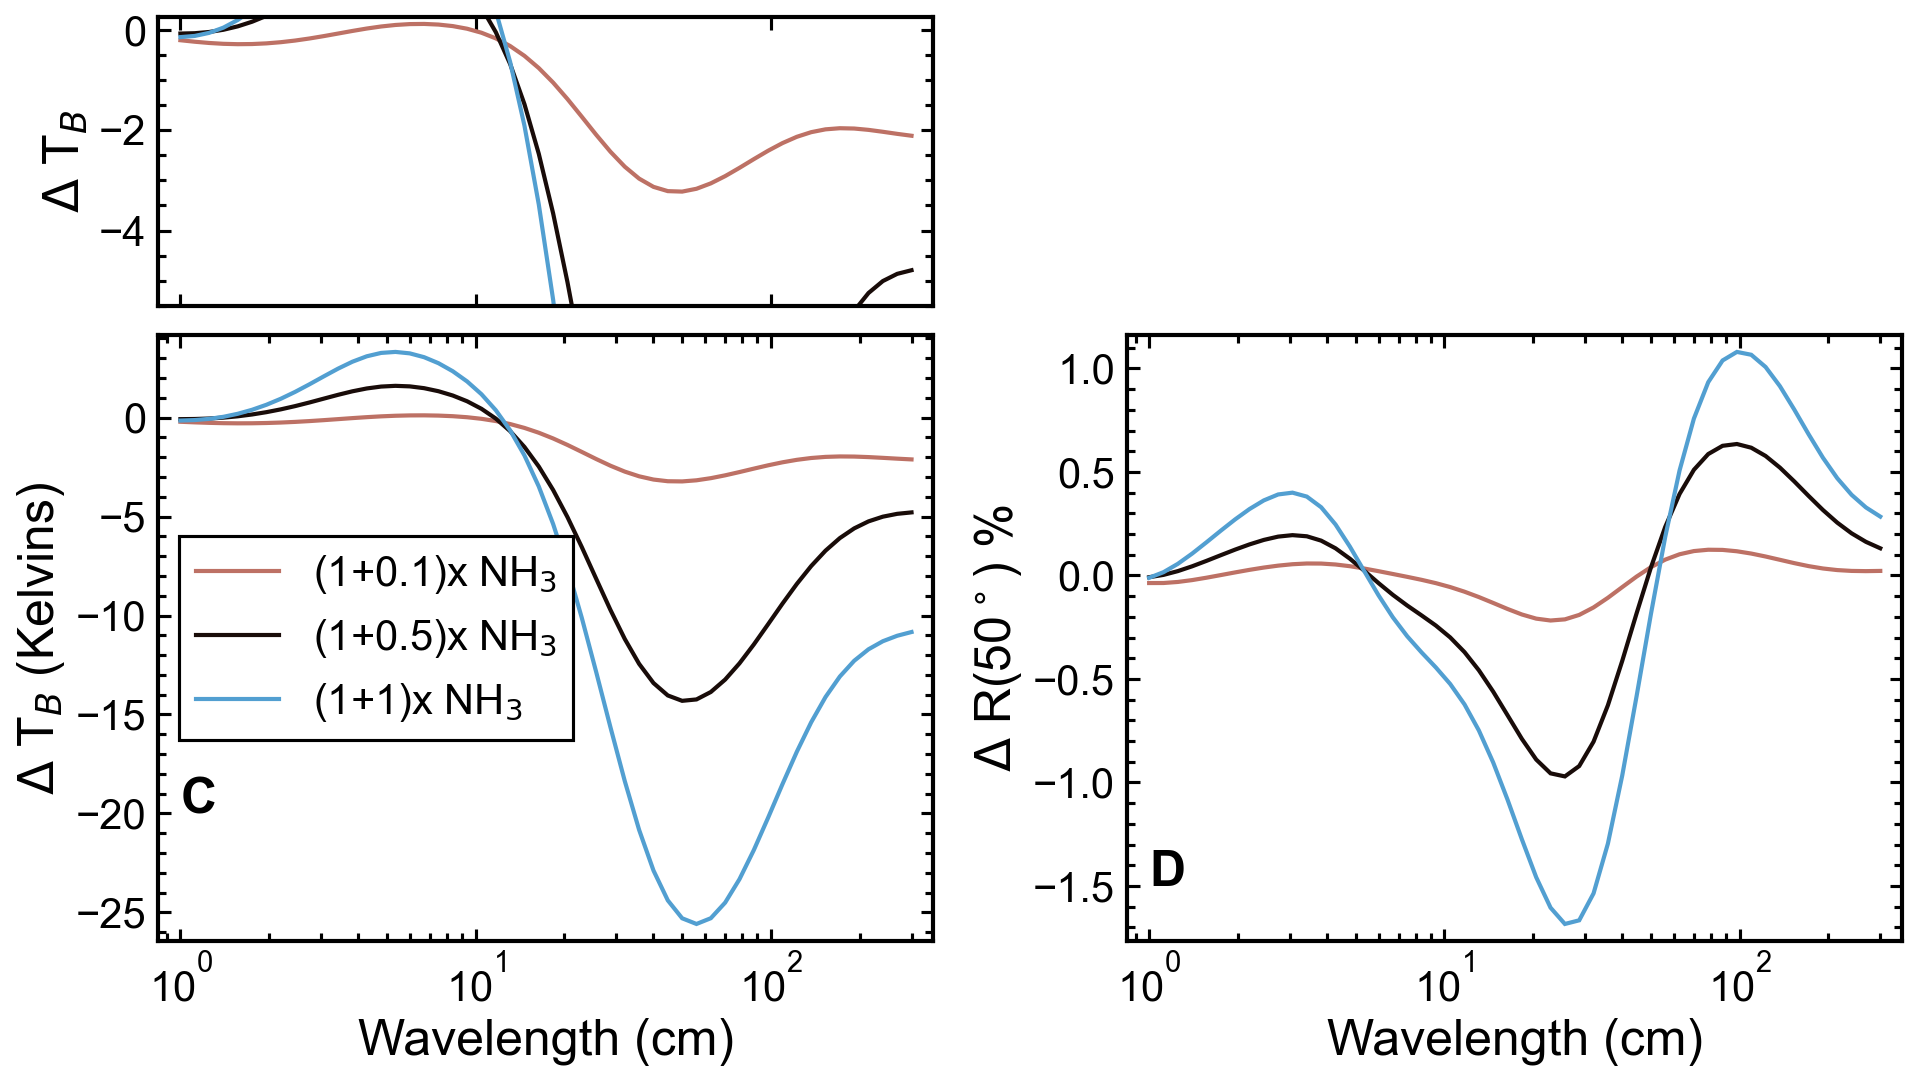

In [ ]:
p_grid = np.logspace(2, 9, 2500)
uranus_gravity = 8.69  # m/s2 
planet_radius = 25559  
freq_ghz = 3e-1 / np.logspace(np.log10(1e-2), np.log10(3), 52)
wave_cm = spc.c / (freq_ghz * 1e9) * 1e2 

# Load RO profile 
data_dir = eccm.__path__[0]
uranus_ro = np.loadtxt(os.path.join(data_dir, 'data/ro_profiles/uranus_voyager2_lindal1987.txt'), skiprows=3, delimiter=',')
uranus_pressure = uranus_ro[:, 0] * 1e2  # Pa
uranus_temperature = uranus_ro[:, 1]

# Baseline
gases1 = eccm.solar_concentration() 
gases = [eccm.GasInput('H2O', deep=35*gases1['O'], rh=0.35), 
         eccm.GasInput('NH3', deep=1*gases1['N'], rh=1.), 
         eccm.GasInput('H2S', deep=35*gases1['S'], rh=0.35), 
         eccm.GasInput('CH4', deep=50*gases1['C'], rh=1.), 
]

result  = eccm.run_eccm(p_grid, uranus_pressure, uranus_temperature, uranus_gravity,
                                                 gases=gases, bulk_h2=0.85, bulk_he=0.15,
                                                 latent_heat_update=True, force_reference_above_pressure=1.*spc.bar, 
                                                 use_compressibility=True)

pressure_grid = result['pressure']
temperature_grid = result['temperature']
altitude_grid = result['altitude']
x_h2o = result['gas_profiles']['H2O']
x_nh3 = result['gas_profiles']['NH3']
x_h2s = result['gas_profiles']['H2S']
x_ch4 = result['gas_profiles']['CH4']
x_ph3 = np.zeros(x_ch4.shape)
x_h2=0.85 * np.ones(x_ch4.shape)
x_he=0.15 * np.ones(x_ch4.shape)

a_h2osolid = result['aerosol_densities']['H2O']['solid']
a_h2oliquid = result['aerosol_densities']['H2O']['liquid']
a_nh3solid = result['aerosol_densities']['NH3']['solid']
a_nh3liquid = result['aerosol_densities']['NH3']['liquid']
a_h2ssolid = result['aerosol_densities']['H2S']['solid']
a_h2sliquid = result['aerosol_densities']['H2S']['liquid']
a_ch4solid = result['aerosol_densities']['CH4']['solid']
a_ch4liquid = result['aerosol_densities']['CH4']['liquid']
a_h2osolution = result['aerosol_densities']['H2O_NH3_SOLUTION']['liquid']
a_nh4sh = result['aerosol_densities']['NH4SH']['solid']

incang_deg = 0. 
# Don't need to use the full atmosphere grid
minloc = np.argmin(abs(pressure_grid / spc.bar - 1e-3))
maxloc = np.argmin(abs(pressure_grid / spc.bar - 1000e3))
slc = slice(maxloc, minloc, 3)
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec1 = Tup 
incang_deg = 50. 
full_tau, _, _, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec2 = Tup 
R50 = (spec1 - spec2) / spec1 * 1e2 
ref_spec = spec1
ref_50 = R50 

# Next 
gases = [eccm.GasInput('H2O', deep=35*gases1['O'], rh=0.35), 
         eccm.GasInput('NH3', deep=1.1*gases1['N'], rh=1.), 
         eccm.GasInput('H2S', deep=35*gases1['S'], rh=0.35), 
         eccm.GasInput('CH4', deep=50*gases1['C'], rh=1.), 
]

result  = eccm.run_eccm(p_grid, uranus_pressure, uranus_temperature, uranus_gravity,
                                                 gases=gases, bulk_h2=0.85, bulk_he=0.15,
                                                 latent_heat_update=True, force_reference_above_pressure=1.*spc.bar, 
                                                 use_compressibility=True)

pressure_grid = result['pressure']
temperature_grid = result['temperature']
altitude_grid = result['altitude']
x_h2o = result['gas_profiles']['H2O']
x_nh3 = result['gas_profiles']['NH3']
x_h2s = result['gas_profiles']['H2S']
x_ch4 = result['gas_profiles']['CH4']
x_ph3 = np.zeros(x_ch4.shape)
x_h2=0.85 * np.ones(x_ch4.shape)
x_he=0.15 * np.ones(x_ch4.shape)

a_h2osolid = result['aerosol_densities']['H2O']['solid']
a_h2oliquid = result['aerosol_densities']['H2O']['liquid']
a_nh3solid = result['aerosol_densities']['NH3']['solid']
a_nh3liquid = result['aerosol_densities']['NH3']['liquid']
a_h2ssolid = result['aerosol_densities']['H2S']['solid']
a_h2sliquid = result['aerosol_densities']['H2S']['liquid']
a_ch4solid = result['aerosol_densities']['CH4']['solid']
a_ch4liquid = result['aerosol_densities']['CH4']['liquid']
a_h2osolution = result['aerosol_densities']['H2O_NH3_SOLUTION']['liquid']
a_nh4sh = result['aerosol_densities']['NH4SH']['solid']

incang_deg = 0. 
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec1 = Tup 
incang_deg = 50. 
full_tau, _, _, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec2 = Tup 
R50 = (spec1 - spec2) / spec1 * 1e2 
spec_1 = spec1
R50_1 = R50


gases = [eccm.GasInput('H2O', deep=35*gases1['O'], rh=0.35), 
         eccm.GasInput('NH3', deep=1.5*gases1['N'], rh=1.), 
         eccm.GasInput('H2S', deep=35*gases1['S'], rh=0.35), 
         eccm.GasInput('CH4', deep=50*gases1['C'], rh=1.), 
]

result  = eccm.run_eccm(p_grid, uranus_pressure, uranus_temperature, uranus_gravity,
                                                 gases=gases, bulk_h2=0.85, bulk_he=0.15,
                                                 latent_heat_update=True, force_reference_above_pressure=1.*spc.bar, 
                                                 use_compressibility=True)

pressure_grid = result['pressure']
temperature_grid = result['temperature']
altitude_grid = result['altitude']
x_h2o = result['gas_profiles']['H2O']
x_nh3 = result['gas_profiles']['NH3']
x_h2s = result['gas_profiles']['H2S']
x_ch4 = result['gas_profiles']['CH4']
x_ph3 = np.zeros(x_ch4.shape)
x_h2=0.85 * np.ones(x_ch4.shape)
x_he=0.15 * np.ones(x_ch4.shape)

a_h2osolid = result['aerosol_densities']['H2O']['solid']
a_h2oliquid = result['aerosol_densities']['H2O']['liquid']
a_nh3solid = result['aerosol_densities']['NH3']['solid']
a_nh3liquid = result['aerosol_densities']['NH3']['liquid']
a_h2ssolid = result['aerosol_densities']['H2S']['solid']
a_h2sliquid = result['aerosol_densities']['H2S']['liquid']
a_ch4solid = result['aerosol_densities']['CH4']['solid']
a_ch4liquid = result['aerosol_densities']['CH4']['liquid']
a_h2osolution = result['aerosol_densities']['H2O_NH3_SOLUTION']['liquid']
a_nh4sh = result['aerosol_densities']['NH4SH']['solid']

incang_deg = 0. 
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec1 = Tup 
incang_deg = 50. 
full_tau, _, _, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec2 = Tup 
R50 = (spec1 - spec2) / spec1 * 1e2 
spec_2 = spec1 
R50_2 = R50

gases = [eccm.GasInput('H2O', deep=35*gases1['O'], rh=0.35), 
         eccm.GasInput('NH3', deep=2.*gases1['N'], rh=1.), 
         eccm.GasInput('H2S', deep=35*gases1['S'], rh=0.35), 
         eccm.GasInput('CH4', deep=50*gases1['C'], rh=1.), 
]

result  = eccm.run_eccm(p_grid, uranus_pressure, uranus_temperature, uranus_gravity,
                                                 gases=gases, bulk_h2=0.85, bulk_he=0.15,
                                                 latent_heat_update=True, force_reference_above_pressure=1.*spc.bar, 
                                                 use_compressibility=True)

pressure_grid = result['pressure']
temperature_grid = result['temperature']
altitude_grid = result['altitude']
x_h2o = result['gas_profiles']['H2O']
x_nh3 = result['gas_profiles']['NH3']
x_h2s = result['gas_profiles']['H2S']
x_ch4 = result['gas_profiles']['CH4']
x_ph3 = np.zeros(x_ch4.shape)
x_h2=0.85 * np.ones(x_ch4.shape)
x_he=0.15 * np.ones(x_ch4.shape)

a_h2osolid = result['aerosol_densities']['H2O']['solid']
a_h2oliquid = result['aerosol_densities']['H2O']['liquid']
a_nh3solid = result['aerosol_densities']['NH3']['solid']
a_nh3liquid = result['aerosol_densities']['NH3']['liquid']
a_h2ssolid = result['aerosol_densities']['H2S']['solid']
a_h2sliquid = result['aerosol_densities']['H2S']['liquid']
a_ch4solid = result['aerosol_densities']['CH4']['solid']
a_ch4liquid = result['aerosol_densities']['CH4']['liquid']
a_h2osolution = result['aerosol_densities']['H2O_NH3_SOLUTION']['liquid']
a_nh4sh = result['aerosol_densities']['NH4SH']['solid']

incang_deg = 0. 
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec1 = Tup 
incang_deg = 50. 
full_tau, _, _, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec2 = Tup 
R50 = (spec1 - spec2) / spec1 * 1e2 
spec_3 = spec1 
R50_3 = R50

fig = plt.figure(figsize=(15, 8))
gs = fig.add_gridspec(nrows=3, ncols=2, hspace=0.1, wspace=0.25)
ax1 = fig.add_subplot(gs[1:, 0])
ax2 = fig.add_subplot(gs[1:, 1])
axins = fig.add_subplot(gs[0, 0])

colors = [
    (189, 113, 101),   
    (25, 12, 9),   
    (82, 159, 209),   
]
colors = [(r/255, g/255, b/255) for r, g, b in colors]

ax1.plot(wave_cm, spec_1-ref_spec, label='(1+0.1)x NH$_3$', lw=2,color=colors[0])
ax2.plot(wave_cm, R50_1-ref_50, lw=2, color=colors[0])
axins.plot(wave_cm, spec_1-ref_spec, lw=2, color=colors[0])

ax1.plot(wave_cm, spec_2-ref_spec, label='(1+0.5)x NH$_3$', color=colors[1], lw=2)
ax2.plot(wave_cm, R50_2-ref_50, color=colors[1], lw=2)
axins.plot(wave_cm, spec_2-ref_spec, color=colors[1], lw=2)


ax1.plot(wave_cm, spec_3-ref_spec, label='(1+1)x NH$_3$', color=colors[2], lw=2)
ax2.plot(wave_cm, R50_3-ref_50, color=colors[2], lw=2)
axins.plot(wave_cm, spec_3-ref_spec, color=colors[2], lw=2)

ax1.set_xlabel('Wavelength (cm)')
ax2.set_xlabel('Wavelength (cm)')
ax1.set_ylabel(r'$\Delta$ T$_B$ (Kelvins)')
ax2.set_ylabel(r'$\Delta$ R(50$^\circ$) %')
axins.set_ylabel(r'$\Delta$ T$_B$')

# ax1.legend(loc='center left') 
ax1.legend()
ax1.set_xscale('log')
ax2.set_xscale('log')
axins.set_xscale('log')
axins.xaxis.minorticks_off()
axins.tick_params(labelbottom=False)
axins.set_ylim(-5.5, 5)
ax1.text(2e2, -24, 'C', weight='bold', fontsize=24)
ax2.text(2e2, -1.5, 'D', weight='bold', fontsize=24)
fig.tight_layout()
fig.savefig('uranus_ammonia.pdf')


### Deep H2S abundance

/var/folders/zg/yqp2bsw569ngkkjdlpj0b5cw0000gq/T/ipykernel_41272/2322039192.py:236: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


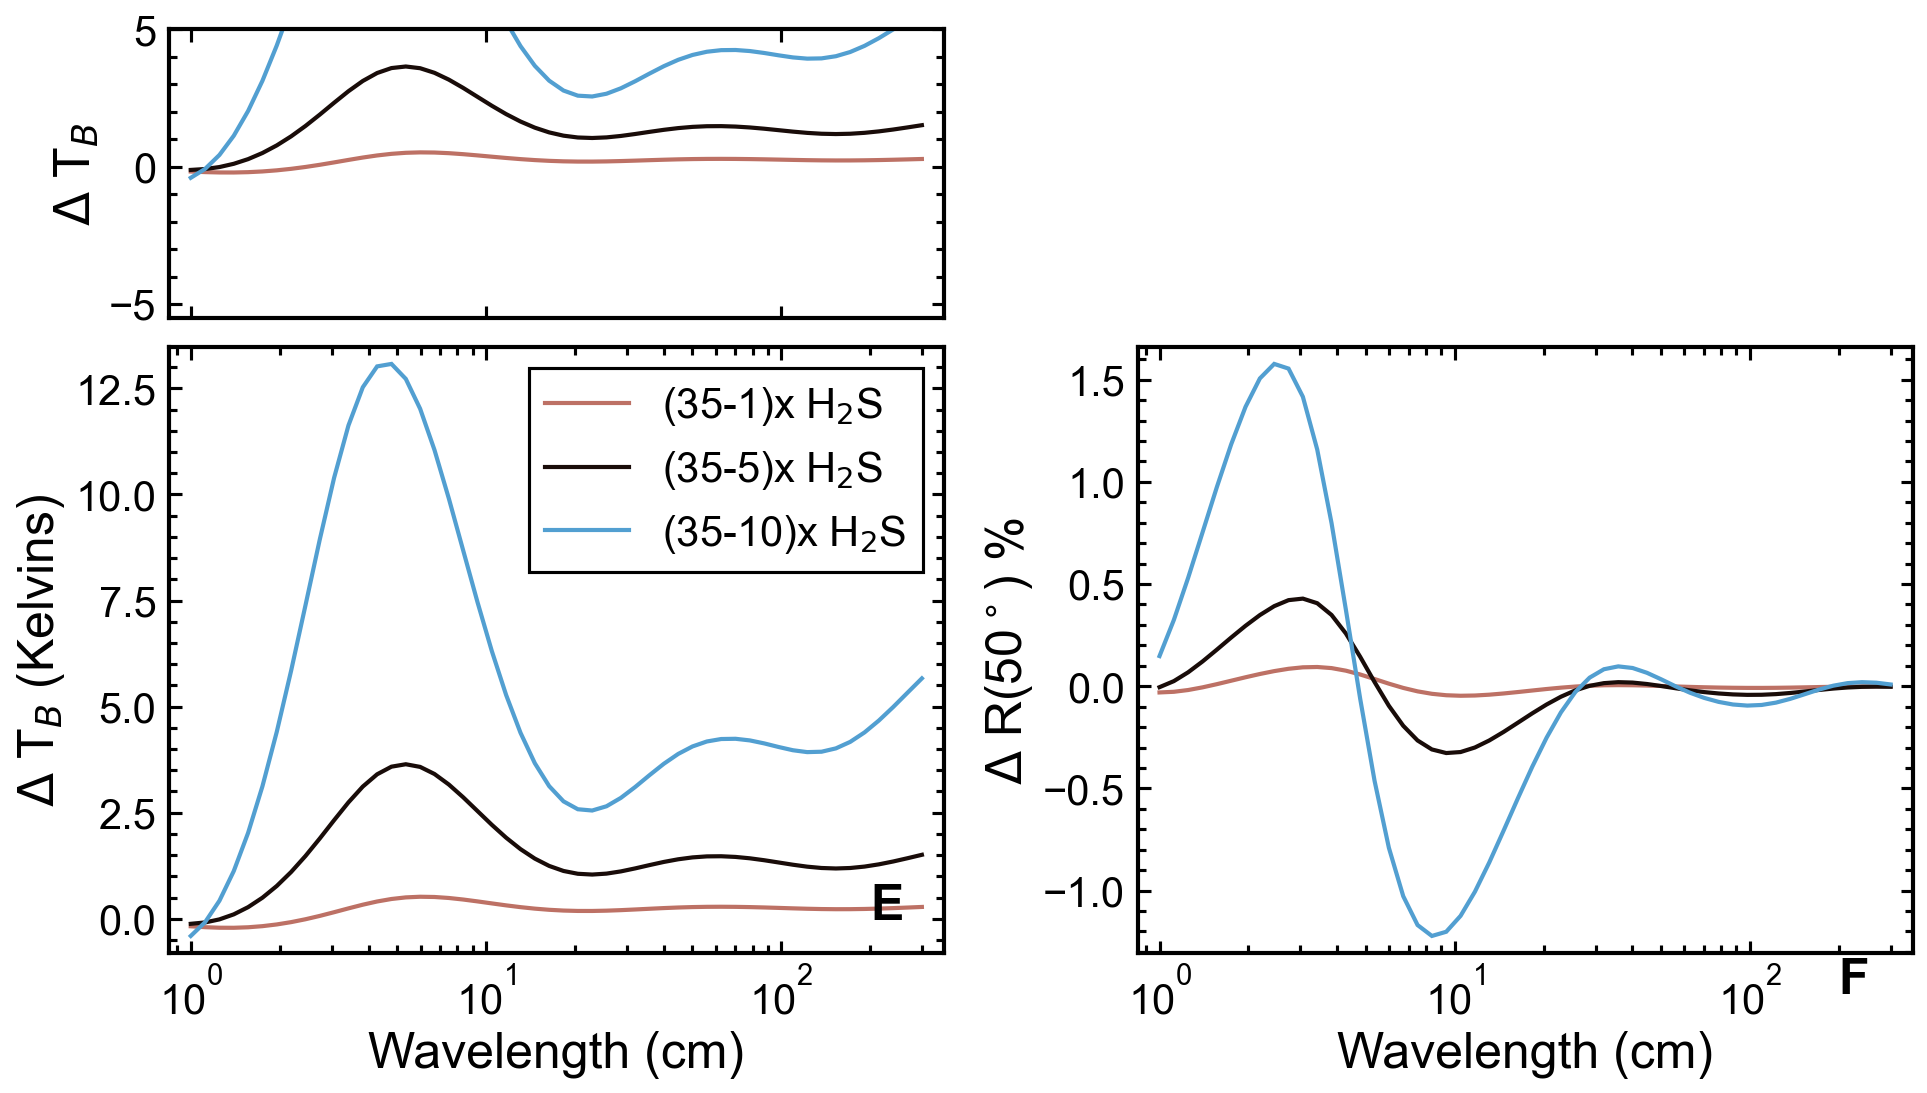

In [ ]:
p_grid = np.logspace(2, 9, 2500)
uranus_gravity = 8.69  # m/s2 
planet_radius = 25559  
freq_ghz = 3e-1 / np.logspace(np.log10(1e-2), np.log10(3), 52)
wave_cm = spc.c / (freq_ghz * 1e9) * 1e2 

# Load RO profile 
data_dir = eccm.__path__[0]
uranus_ro = np.loadtxt(os.path.join(data_dir, 'data/ro_profiles/uranus_voyager2_lindal1987.txt'), skiprows=3, delimiter=',')
uranus_pressure = uranus_ro[:, 0] * 1e2  # Pa
uranus_temperature = uranus_ro[:, 1]

# Baseline
gases1 = eccm.solar_concentration() 
gases = [eccm.GasInput('H2O', deep=35*gases1['O'], rh=0.35), 
         eccm.GasInput('NH3', deep=1*gases1['N'], rh=1.), 
         eccm.GasInput('H2S', deep=35*gases1['S'], rh=0.35), 
         eccm.GasInput('CH4', deep=50*gases1['C'], rh=1.), 
]

result  = eccm.run_eccm(p_grid, uranus_pressure, uranus_temperature, uranus_gravity,
                                                 gases=gases, bulk_h2=0.85, bulk_he=0.15,
                                                 latent_heat_update=True, force_reference_above_pressure=1.*spc.bar, 
                                                 use_compressibility=True)

pressure_grid = result['pressure']
temperature_grid = result['temperature']
altitude_grid = result['altitude']
x_h2o = result['gas_profiles']['H2O']
x_nh3 = result['gas_profiles']['NH3']
x_h2s = result['gas_profiles']['H2S']
x_ch4 = result['gas_profiles']['CH4']
x_ph3 = np.zeros(x_ch4.shape)
x_h2=0.85 * np.ones(x_ch4.shape)
x_he=0.15 * np.ones(x_ch4.shape)

a_h2osolid = result['aerosol_densities']['H2O']['solid']
a_h2oliquid = result['aerosol_densities']['H2O']['liquid']
a_nh3solid = result['aerosol_densities']['NH3']['solid']
a_nh3liquid = result['aerosol_densities']['NH3']['liquid']
a_h2ssolid = result['aerosol_densities']['H2S']['solid']
a_h2sliquid = result['aerosol_densities']['H2S']['liquid']
a_ch4solid = result['aerosol_densities']['CH4']['solid']
a_ch4liquid = result['aerosol_densities']['CH4']['liquid']
a_h2osolution = result['aerosol_densities']['H2O_NH3_SOLUTION']['liquid']
a_nh4sh = result['aerosol_densities']['NH4SH']['solid']


incang_deg = 0. 
# Don't need to use the full atmosphere grid
minloc = np.argmin(abs(pressure_grid / spc.bar - 1e-3))
maxloc = np.argmin(abs(pressure_grid / spc.bar - 1000e3))
slc = slice(maxloc, minloc, 3)
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec1 = Tup 
incang_deg = 50. 
full_tau, _, _, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec2 = Tup 
R50 = (spec1 - spec2) / spec1 * 1e2 
ref_spec = spec1
ref_50 = R50 

# Next 
gases = [eccm.GasInput('H2O', deep=35*gases1['O'], rh=0.35), 
         eccm.GasInput('NH3', deep=1*gases1['N'], rh=1.), 
         eccm.GasInput('H2S', deep=34*gases1['S'], rh=0.35), 
         eccm.GasInput('CH4', deep=50*gases1['C'], rh=1.), 
]

result  = eccm.run_eccm(p_grid, uranus_pressure, uranus_temperature, uranus_gravity,
                                                 gases=gases, bulk_h2=0.85, bulk_he=0.15,
                                                 latent_heat_update=True, force_reference_above_pressure=1.*spc.bar, 
                                                 use_compressibility=True)

pressure_grid = result['pressure']
temperature_grid = result['temperature']
altitude_grid = result['altitude']
x_h2o = result['gas_profiles']['H2O']
x_nh3 = result['gas_profiles']['NH3']
x_h2s = result['gas_profiles']['H2S']
x_ch4 = result['gas_profiles']['CH4']
x_ph3 = np.zeros(x_ch4.shape)
x_h2=0.85 * np.ones(x_ch4.shape)
x_he=0.15 * np.ones(x_ch4.shape)

a_h2osolid = result['aerosol_densities']['H2O']['solid']
a_h2oliquid = result['aerosol_densities']['H2O']['liquid']
a_nh3solid = result['aerosol_densities']['NH3']['solid']
a_nh3liquid = result['aerosol_densities']['NH3']['liquid']
a_h2ssolid = result['aerosol_densities']['H2S']['solid']
a_h2sliquid = result['aerosol_densities']['H2S']['liquid']
a_ch4solid = result['aerosol_densities']['CH4']['solid']
a_ch4liquid = result['aerosol_densities']['CH4']['liquid']
a_h2osolution = result['aerosol_densities']['H2O_NH3_SOLUTION']['liquid']
a_nh4sh = result['aerosol_densities']['NH4SH']['solid']

incang_deg = 0. 
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec1 = Tup 
incang_deg = 50. 
full_tau, _, _, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec2 = Tup 
R50 = (spec1 - spec2) / spec1 * 1e2 
spec_1 = spec1 
R50_1 = R50

gases = [eccm.GasInput('H2O', deep=35*gases1['O'], rh=0.35), 
         eccm.GasInput('NH3', deep=1*gases1['N'], rh=1.), 
         eccm.GasInput('H2S', deep=30*gases1['S'], rh=0.35), 
         eccm.GasInput('CH4', deep=50*gases1['C'], rh=1.), 
]

result  = eccm.run_eccm(p_grid, uranus_pressure, uranus_temperature, uranus_gravity,
                                                 gases=gases, bulk_h2=0.85, bulk_he=0.15,
                                                 latent_heat_update=True, force_reference_above_pressure=1.*spc.bar, 
                                                 use_compressibility=True)

pressure_grid = result['pressure']
temperature_grid = result['temperature']
altitude_grid = result['altitude']
x_h2o = result['gas_profiles']['H2O']
x_nh3 = result['gas_profiles']['NH3']
x_h2s = result['gas_profiles']['H2S']
x_ch4 = result['gas_profiles']['CH4']
x_ph3 = np.zeros(x_ch4.shape)
x_h2=0.85 * np.ones(x_ch4.shape)
x_he=0.15 * np.ones(x_ch4.shape)

a_h2osolid = result['aerosol_densities']['H2O']['solid']
a_h2oliquid = result['aerosol_densities']['H2O']['liquid']
a_nh3solid = result['aerosol_densities']['NH3']['solid']
a_nh3liquid = result['aerosol_densities']['NH3']['liquid']
a_h2ssolid = result['aerosol_densities']['H2S']['solid']
a_h2sliquid = result['aerosol_densities']['H2S']['liquid']
a_ch4solid = result['aerosol_densities']['CH4']['solid']
a_ch4liquid = result['aerosol_densities']['CH4']['liquid']
a_h2osolution = result['aerosol_densities']['H2O_NH3_SOLUTION']['liquid']
a_nh4sh = result['aerosol_densities']['NH4SH']['solid']

incang_deg = 0. 
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec1 = Tup 
incang_deg = 50. 
full_tau, _, _, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec2 = Tup 
R50 = (spec1 - spec2) / spec1 * 1e2 
spec_2 = spec1 
R50_2 = R50


gases = [eccm.GasInput('H2O', deep=35*gases1['O'], rh=0.35), 
         eccm.GasInput('NH3', deep=1*gases1['N'], rh=1.), 
         eccm.GasInput('H2S', deep=20*gases1['S'], rh=0.35), 
         eccm.GasInput('CH4', deep=50*gases1['C'], rh=1.), 
]

result  = eccm.run_eccm(p_grid, uranus_pressure, uranus_temperature, uranus_gravity,
                                                 gases=gases, bulk_h2=0.85, bulk_he=0.15,
                                                 latent_heat_update=True, force_reference_above_pressure=1.*spc.bar, 
                                                 use_compressibility=True)

pressure_grid = result['pressure']
temperature_grid = result['temperature']
altitude_grid = result['altitude']
x_h2o = result['gas_profiles']['H2O']
x_nh3 = result['gas_profiles']['NH3']
x_h2s = result['gas_profiles']['H2S']
x_ch4 = result['gas_profiles']['CH4']
x_ph3 = np.zeros(x_ch4.shape)
x_h2=0.85 * np.ones(x_ch4.shape)
x_he=0.15 * np.ones(x_ch4.shape)

a_h2osolid = result['aerosol_densities']['H2O']['solid']
a_h2oliquid = result['aerosol_densities']['H2O']['liquid']
a_nh3solid = result['aerosol_densities']['NH3']['solid']
a_nh3liquid = result['aerosol_densities']['NH3']['liquid']
a_h2ssolid = result['aerosol_densities']['H2S']['solid']
a_h2sliquid = result['aerosol_densities']['H2S']['liquid']
a_ch4solid = result['aerosol_densities']['CH4']['solid']
a_ch4liquid = result['aerosol_densities']['CH4']['liquid']
a_h2osolution = result['aerosol_densities']['H2O_NH3_SOLUTION']['liquid']
a_nh4sh = result['aerosol_densities']['NH4SH']['solid']

incang_deg = 0. 
full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec1 = Tup 
incang_deg = 50. 
full_tau, _, _, Tup, Tlimb = mrtm.mrtm(freq_ghz, incang_deg, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
spec2 = Tup 
R50 = (spec1 - spec2) / spec1 * 1e2 
spec_3 = spec1 
R50_3 = R50

fig = plt.figure(figsize=(15, 8))
gs = fig.add_gridspec(nrows=3, ncols=2, hspace=0.1, wspace=0.25)
ax1 = fig.add_subplot(gs[1:, 0])
ax2 = fig.add_subplot(gs[1:, 1])
axins = fig.add_subplot(gs[0, 0])

colors = [
    (189, 113, 101),   
    (25, 12, 9),   
    (82, 159, 209),   
]
colors = [(r/255, g/255, b/255) for r, g, b in colors]

ax1.plot(wave_cm, spec_1-ref_spec, label='(35-1)x H$_2$S', lw=2,color=colors[0])
ax2.plot(wave_cm, R50_1-ref_50, lw=2, color=colors[0])
axins.plot(wave_cm, spec_1-ref_spec, lw=2, color=colors[0])

ax1.plot(wave_cm, spec_2-ref_spec, label='(35-5)x H$_2$S', color=colors[1], lw=2)
ax2.plot(wave_cm, R50_2-ref_50, color=colors[1], lw=2)
axins.plot(wave_cm, spec_2-ref_spec, color=colors[1], lw=2)


ax1.plot(wave_cm, spec_3-ref_spec, label='(35-10)x H$_2$S', color=colors[2], lw=2)
ax2.plot(wave_cm, R50_3-ref_50, color=colors[2], lw=2)
axins.plot(wave_cm, spec_3-ref_spec, color=colors[2], lw=2)

ax1.set_xlabel('Wavelength (cm)')
ax2.set_xlabel('Wavelength (cm)')
ax1.set_ylabel(r'$\Delta$ T$_B$ (Kelvins)')
ax2.set_ylabel(r'$\Delta$ R(50$^\circ$) %')
axins.set_ylabel(r'$\Delta$ T$_B$')

# ax1.legend(loc='center left') 
ax1.legend()
ax1.set_xscale('log')
ax2.set_xscale('log')
axins.set_xscale('log')
axins.xaxis.minorticks_off()
axins.tick_params(labelbottom=False)
axins.set_ylim(-0.5, 1)
ax1.text(2e2, 0.33, 'E', weight='bold', fontsize=24)
ax2.text(2e2, -1.07, 'F', weight='bold', fontsize=24)
fig.tight_layout()
fig.savefig('uranus_h2s.pdf')
